# EEC 289A — Sensorimotor Learning: RL Benchmark
**PPO vs Neural Dyna-Q vs Dreamer on MiniGrid Sparse-Reward Navigation**

Team: Pranav Manimaran, Vandana Mansur

---
**Runtime:** Enable GPU in `Runtime → Change runtime type → T4 GPU`

**Quick smoke test** (~3–6 hrs): Set `SMOKE_TEST = False` and re-run from S8.

### Notebook structure
| Section | Contents |
|---------|----------|
| 1–4 | Install, imports, env utilities, shared CNN + CSV infrastructure |
| 5–7 | PPO, Neural Dyna-Q, Dreamer training functions |
| 8–9 | Config + smoke test |
| 10 | Full 36-run benchmark loop (skip if SMOKE_TEST=True) |
| 11 | Load all CSV logs (handles ablation suffixes `_k{K}`, `_h{H}`) |
| 12 | **Fig 1** Learning curves (2×2 grid) + **Fig 2** Sample efficiency bars + table |
| 13 | **Fig 3** Wall-clock time + gradient norm diagnostics |
| 14 | **Fig 4** Generalization heatmap (8×8 → 16×16 zero-shot) |
| 15 | **Fig 10/11** Ablation sweeps (Dyna-Q k, Dreamer H) |
| 16 | Download results.zip |

This notebook is **completely self-contained** — no external files needed. Run cells top-to-bottom.

## 1. Install Dependencies

In [1]:
!pip install -q minigrid gymnasium torch numpy matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 156.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile, os, glob

os.makedirs("results", exist_ok=True)
zip_path = "/content/drive/MyDrive/results-Full Run-First Try.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("results/")

n = len(glob.glob("results/logs/*.csv"))
print(f"{n} CSV files restored — ready to continue training")

27 CSV files restored — ready to continue training


## 2. Imports

In [4]:
import collections
import csv
import os
import random
import time
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

import gymnasium as gym
from minigrid.wrappers import FullyObsWrapper, ImgObsWrapper

print('Imports OK')

Imports OK


## 3. Environment Utilities

In [5]:
# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ---------------------------------------------------------------------------
# Environment maps
# ---------------------------------------------------------------------------

ENV_MAP = {
    "empty":       "MiniGrid-Empty-8x8-v0",
    "doorkey":     "MiniGrid-DoorKey-8x8-v0",
    "multiroom":   "MiniGrid-MultiRoom-N4-S5-v0",
    "keycorridor": "MiniGrid-KeyCorridorS3R1-v0",
}

MAX_STEPS_MAP = {
    "empty":       128,
    "doorkey":     300,
    "multiroom":   250,
    "keycorridor": 200,
}

# 16×16 variants for zero-shot generalization eval (plan.txt §5.3)
GEN_ENV_MAP = {
    "empty":       "MiniGrid-Empty-16x16-v0",
    "doorkey":     "MiniGrid-DoorKey-16x16-v0",
    "multiroom":   "MiniGrid-MultiRoom-N6-v0",
    "keycorridor": "MiniGrid-KeyCorridorS4R3-v0",
}
GEN_MAX_STEPS_MAP = {
    "empty": 512, "doorkey": 1200, "multiroom": 1000, "keycorridor": 800,
}


class NormalizeObs(gym.ObservationWrapper):
    """Transpose (H,W,C) -> (C,H,W) and normalize to [0,1] float32."""

    def __init__(self, env):
        super().__init__(env)
        obs_shape = env.observation_space.shape  # (H, W, C)
        H, W, C = obs_shape
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=(C, H, W), dtype=np.float32
        )
        self._channel_max = np.array([10.0, 5.0, 2.0], dtype=np.float32)

    def observation(self, obs):
        obs = obs.astype(np.float32)
        obs = obs / self._channel_max[None, None, :]
        obs = obs.transpose(2, 0, 1)
        return obs.copy()


class MaskDoneAction(gym.ActionWrapper):
    """Drop action index 6 (MiniGrid 'done' no-op) to keep effective action space at 6."""

    def __init__(self, env):
        super().__init__(env)
        self.action_space = gym.spaces.Discrete(6)

    def action(self, act):
        return int(act)


def make_env(env_key: str, seed: int, max_steps: int = None):
    env_id = ENV_MAP[env_key]
    if max_steps is None:
        max_steps = MAX_STEPS_MAP[env_key]
    env = gym.make(env_id, max_steps=max_steps)
    env = FullyObsWrapper(env)
    env = ImgObsWrapper(env)
    env = NormalizeObs(env)
    env = MaskDoneAction(env)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env


def obs_to_tensor(obs: np.ndarray, device: torch.device) -> torch.Tensor:
    return torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)


print('Environment utilities OK')

Environment utilities OK


## 4. Shared Infrastructure (CNN Encoder, Logger, Eval)

In [6]:
# ---------------------------------------------------------------------------
# Shared CNN Encoder
# ---------------------------------------------------------------------------

class CNNEncoder(nn.Module):
    """
    Encodes a (B, C, H, W) MiniGrid observation into a (B, 256) feature vector.
    AdaptiveAvgPool2d(4,4) means this works for ANY grid size — 8x8 or 16x16.
    GroupNorm works correctly at batch_size=1 (unlike BatchNorm).
    """

    def __init__(self, obs_shape):
        super().__init__()
        C, H, W = obs_shape
        self.conv = nn.Sequential(
            nn.Conv2d(C, 32, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=64),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(inplace=True),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.pool(x)
        return self.fc(x)


# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------

class CSVLogger:
    def __init__(self, path: str):
        self.path = path
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self._file = open(path, "w", newline="")
        self._writer = None
        self._start = time.time()

    def write(self, row: dict):
        full_row = {**row, "wall_time_sec": round(time.time() - self._start, 2)}
        if self._writer is None:
            self._writer = csv.DictWriter(self._file, fieldnames=list(full_row.keys()))
            self._writer.writeheader()
        self._writer.writerow(full_row)
        self._file.flush()

    def close(self):
        if not self._file.closed:
            self._file.close()

    def __del__(self):
        if hasattr(self, '_file'):
            self.close()


# ---------------------------------------------------------------------------
# Evaluation + Checkpointing
# ---------------------------------------------------------------------------

def evaluate_agent(act_fn, env_key: str, seed: int, n_episodes: int = 20,
                   device: torch.device = torch.device("cpu")) -> dict:
    """Run n_episodes deterministic episodes and return metrics dict."""
    env = make_env(env_key, seed=seed + 10000)
    successes, ep_lengths, ep_returns = [], [], []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_len = 0
        ep_ret = 0.0
        while not done:
            with torch.no_grad():
                action = act_fn(obs_to_tensor(obs, device))
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_len += 1
            ep_ret += float(reward)
        successes.append(1 if (terminated and ep_ret > 0) else 0)
        ep_lengths.append(ep_len)
        ep_returns.append(ep_ret)
    env.close()
    return {
        "success_rate": float(np.mean(successes)),
        "mean_ep_length": float(np.mean(ep_lengths)),
        "mean_return": float(np.mean(ep_returns)),
    }


def save_checkpoint(state_dict: dict, path: str):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(state_dict, path)


def _find_latest_checkpoint(save_dir: str, agent: str, env_key: str, seed: int):
    """Return path to the latest checkpoint for (agent, env, seed), or None."""
    ckpt_dir = os.path.join(save_dir, "checkpoints")
    if not os.path.isdir(ckpt_dir):
        return None
    prefix = f"{agent}_{env_key}_seed{seed}_step"
    candidates = [f for f in os.listdir(ckpt_dir)
                  if f.startswith(prefix) and f.endswith(".pt")]
    if not candidates:
        return None
    candidates.sort(key=lambda f: int(re.search(r"_step(\d+)\.pt$", f).group(1)))
    return os.path.join(ckpt_dir, candidates[-1])


def _append_gen_result(path: str, agent: str, env: str, seed: int, rate: float):
    """Append a row to generalization_results.csv (creates with header if new)."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    write_header = not os.path.exists(path)
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["agent", "env", "seed", "gen_success_rate_16x16"])
        if write_header:
            writer.writeheader()
        writer.writerow({"agent": agent, "env": env, "seed": seed,
                         "gen_success_rate_16x16": round(rate, 4)})


def load_checkpoint_and_eval_generalization(
        agent: str, ckpt_path: str, env_key: str,
        obs_shape, n_actions: int, device: torch.device,
        n_episodes: int = 50) -> float:
    """Zero-shot eval of a trained 8×8 checkpoint on the 16×16 variant.
    AdaptiveAvgPool2d in CNNEncoder handles the size difference transparently.
    """
    if env_key not in GEN_ENV_MAP:
        print(f"  [gen_eval] No 16x16 variant defined for '{env_key}' — skipping.")
        return float("nan")

    env = gym.make(GEN_ENV_MAP[env_key], max_steps=GEN_MAX_STEPS_MAP[env_key])
    env = FullyObsWrapper(env); env = ImgObsWrapper(env)
    env = NormalizeObs(env);    env = MaskDoneAction(env)
    env.reset(seed=99999)

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    if agent == "ppo":
        net = PPOActorCritic(obs_shape, n_actions).to(device)
        net.load_state_dict(ckpt["net"]); net.eval()
        act_fn = lambda o: net.act(o, deterministic=True)[0]
        dreamer_mode = False
    elif agent == "dynaq":
        online_net = DynaQNetwork(obs_shape, n_actions).to(device)
        online_net.load_state_dict(ckpt["online_net"]); online_net.eval()
        act_fn = lambda o: online_net(o).argmax(dim=1).item()
        dreamer_mode = False
    elif agent == "dreamer":
        z_dim = 32
        rssm_g = RSSM(obs_shape, n_actions).to(device)
        ac_g   = LatentActorCritic(state_dim=512 + z_dim, n_actions=n_actions).to(device)
        rssm_g.load_state_dict(ckpt["rssm"])
        ac_g.actor.load_state_dict(ckpt["actor"])
        rssm_g.eval(); ac_g.eval()
        act_fn = None; dreamer_mode = True
    else:
        env.close(); return float("nan")

    successes = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False; ep_ret = 0.0; terminated = False
        if dreamer_mode:
            h = rssm_g.init_hidden(1, device)
            z = torch.zeros(1, z_dim, device=device)
            prev_a = torch.zeros(1, dtype=torch.long, device=device)
        while not done:
            with torch.no_grad():
                obs_t = obs_to_tensor(obs, device)
                if dreamer_mode:
                    h, z_post, *_ = rssm_g.observe_step(h, obs_t, prev_a, z)
                    z = z_post
                    action_t, *_ = ac_g.act(rssm_g.world_state(h, z), deterministic=True)
                    action = action_t.item()
                    prev_a = action_t.unsqueeze(0) if action_t.dim() == 0 else action_t
                else:
                    action = act_fn(obs_t)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_ret += float(reward)
        successes.append(1 if (terminated and ep_ret > 0) else 0)
    env.close()
    return float(np.mean(successes))


# ---------------------------------------------------------------------------
# Replay Buffer (used by Neural Dyna-Q)
# ---------------------------------------------------------------------------

class ReplayBuffer:
    """Circular replay buffer. Stored on CPU; sample() moves to compute device."""

    def __init__(self, capacity: int, obs_shape, device: torch.device):
        self.capacity = capacity
        self.device = device
        self.obs      = torch.zeros(capacity, *obs_shape)
        self.actions  = torch.zeros(capacity, dtype=torch.long)
        self.rewards  = torch.zeros(capacity)
        self.next_obs = torch.zeros(capacity, *obs_shape)
        self.dones    = torch.zeros(capacity)
        self.ptr = 0
        self.size = 0

    def push(self, obs, action, reward, next_obs, done):
        self.obs[self.ptr]      = torch.as_tensor(obs)
        self.actions[self.ptr]  = action
        self.rewards[self.ptr]  = reward
        self.next_obs[self.ptr] = torch.as_tensor(next_obs)
        self.dones[self.ptr]    = float(done)
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int, device: torch.device = None):
        idx = np.random.randint(0, self.size, size=batch_size)
        d = device if device is not None else self.device
        return (
            self.obs[idx].to(d),
            self.actions[idx].to(d),
            self.rewards[idx].to(d),
            self.next_obs[idx].to(d),
            self.dones[idx].to(d),
        )

    def __len__(self):
        return self.size


print('Shared infrastructure OK')

Shared infrastructure OK


## 5. Agent 1 — PPO (Proximal Policy Optimization)

PPO is the **model-free baseline** in this benchmark. At each iteration it collects a fixed-length rollout buffer (T steps) of (obs, action, reward, done) tuples using the current stochastic policy, then runs K epochs of minibatch gradient updates:

- **Clipped policy objective**: maximises $r_t(\theta) = \pi_\theta(a|s)/\pi_{\theta_\text{old}}(a|s)$, clipped to $[1-\varepsilon, 1+\varepsilon]$ to prevent destructive updates.
- **Value function loss**: MSE between the critic $V_\theta(s)$ and the GAE-$\lambda$ bootstrapped return.
- **Entropy bonus**: penalises low-entropy policies to maintain exploration.

**Gradient tracking**: `clip_grad_norm_()` returns the pre-clip norm; PPO averages it over all minibatch steps per rollout and logs `grad_norm` to the CSV.

**Why it's the baseline**: PPO requires no environment model. It is sample-hungry but well-understood. On sparse-reward MiniGrid it struggles — every gradient step is reactive, success relies on stumbling upon the goal by random exploration before the signal becomes useful.

Key hyperparameters: `clip_eps=0.2`, `gae_lambda=0.95`, `rollout_len=128`, `ppo_epochs=4`, `max_grad_norm=0.5`.

In [7]:
# ===========================================================================
# AGENT 1: PPO
# ===========================================================================

class PPOActorCritic(nn.Module):
    def __init__(self, obs_shape, n_actions: int):
        super().__init__()
        self.encoder = CNNEncoder(obs_shape)
        self.actor = nn.Linear(256, n_actions)
        self.critic = nn.Linear(256, 1)
        nn.init.orthogonal_(self.actor.weight, gain=0.01)
        nn.init.zeros_(self.actor.bias)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.zeros_(self.critic.bias)

    def forward(self, obs: torch.Tensor):
        z = self.encoder(obs)
        dist = Categorical(logits=self.actor(z))
        value = self.critic(z).squeeze(-1)
        return dist, value

    def act(self, obs: torch.Tensor, deterministic: bool = False):
        dist, value = self(obs)
        action = dist.mode if deterministic else dist.sample()
        return action.item(), dist.log_prob(action), value


class PPORolloutBuffer:
    def __init__(self, n_steps: int, obs_shape, device: torch.device):
        self.n_steps = n_steps
        self.device = device
        self.obs        = torch.zeros(n_steps, *obs_shape, device=device)
        self.actions    = torch.zeros(n_steps, dtype=torch.long, device=device)
        self.log_probs  = torch.zeros(n_steps, device=device)
        self.rewards    = torch.zeros(n_steps, device=device)
        self.values     = torch.zeros(n_steps, device=device)
        self.dones      = torch.zeros(n_steps, device=device)
        self.advantages = torch.zeros(n_steps, device=device)
        self.returns    = torch.zeros(n_steps, device=device)
        self.ptr = 0

    def store(self, obs, action, log_prob, reward, value, done):
        self.obs[self.ptr]       = obs
        self.actions[self.ptr]   = action
        self.log_probs[self.ptr] = log_prob
        self.rewards[self.ptr]   = reward
        self.values[self.ptr]    = value
        self.dones[self.ptr]     = done
        self.ptr += 1

    def compute_gae(self, last_value: float, gamma: float = 0.99,
                    gae_lambda: float = 0.95):
        last_gae = 0.0
        for t in reversed(range(self.n_steps)):
            next_value = last_value if t == self.n_steps - 1 else float(self.values[t + 1])
            next_non_terminal = 1.0 - float(self.dones[t])
            delta = (float(self.rewards[t])
                     + gamma * next_value * next_non_terminal
                     - float(self.values[t]))
            last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
            self.advantages[t] = last_gae
        self.returns = self.advantages + self.values

    def get_minibatches(self, batch_size: int):
        indices = torch.randperm(self.n_steps, device=self.device)
        for start in range(0, self.n_steps, batch_size):
            idx = indices[start:start + batch_size]
            yield (self.obs[idx], self.actions[idx], self.advantages[idx],
                   self.returns[idx], self.log_probs[idx])

    def reset(self):
        self.ptr = 0


def train_ppo(env_key: str, seed: int, total_steps: int, save_dir: str,
              device: torch.device):
    set_seed(seed)
    env = make_env(env_key, seed)
    obs_shape = env.observation_space.shape
    n_actions = env.action_space.n

    net = PPOActorCritic(obs_shape, n_actions).to(device)
    initial_lr = 3e-4
    optimizer = torch.optim.Adam(net.parameters(), lr=initial_lr, eps=1e-5)

    n_steps       = 2048
    n_epochs      = 10
    batch_size    = 64
    gamma         = 0.99
    gae_lambda    = 0.95
    clip_eps      = 0.2
    value_coef    = 0.5
    entropy_coef  = 0.01
    max_grad_norm = 0.5
    eval_interval = 10_000
    ckpt_interval = 50_000

    buffer = PPORolloutBuffer(n_steps, obs_shape, device)
    log_path = os.path.join(save_dir, "logs", f"ppo_{env_key}_seed{seed}.csv")
    logger = CSVLogger(log_path)

    global_step = 0
    last_eval_step = -eval_interval
    last_ckpt_step = -ckpt_interval
    obs, _ = env.reset()

    def lr_at_step(s):
        frac = 1.0 - s / total_steps
        for pg in optimizer.param_groups:
            pg["lr"] = initial_lr * frac

    print(f"[PPO] env={env_key} seed={seed} total_steps={total_steps}")

    while global_step < total_steps:
        buffer.reset()
        net.train()

        for _ in range(n_steps):
            obs_t = obs_to_tensor(obs, device)
            with torch.no_grad():
                action, log_prob, value = net.act(obs_t)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.store(
                obs_t.squeeze(0), action, log_prob.item(),
                reward, value.item(), float(done)
            )
            if done:
                obs, _ = env.reset()
            else:
                obs = next_obs
            global_step += 1

        with torch.no_grad():
            _, last_val = net(obs_to_tensor(obs, device))
        buffer.compute_gae(last_val.item(), gamma, gae_lambda)

        p_losses, v_losses, entropies, grad_norms = [], [], [], []
        for _ in range(n_epochs):
            for obs_b, act_b, adv_b, ret_b, old_lp_b in buffer.get_minibatches(batch_size):
                adv_b = (adv_b - adv_b.mean()) / (adv_b.std() + 1e-8)
                dist, value = net(obs_b)
                new_lp = dist.log_prob(act_b)
                entropy = dist.entropy().mean()

                ratio = (new_lp - old_lp_b).exp()
                surr1 = ratio * adv_b
                surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv_b
                policy_loss = -torch.min(surr1, surr2).mean()

                value_loss = F.mse_loss(value, ret_b)
                loss = policy_loss + value_coef * value_loss - entropy_coef * entropy

                optimizer.zero_grad()
                loss.backward()
                gn = nn.utils.clip_grad_norm_(net.parameters(), max_grad_norm).item()
                optimizer.step()

                p_losses.append(policy_loss.item())
                v_losses.append(value_loss.item())
                entropies.append(entropy.item())
                grad_norms.append(gn)

        lr_at_step(global_step)

        if global_step - last_eval_step >= eval_interval:
            last_eval_step = global_step
            net.eval()
            act_fn = lambda o: net.act(o, deterministic=True)[0]
            metrics = evaluate_agent(act_fn, env_key, seed, n_episodes=20, device=device)
            row = {
                "step": global_step,
                "success_rate": metrics["success_rate"],
                "mean_ep_length": metrics["mean_ep_length"],
                "mean_return": metrics["mean_return"],
                "policy_loss": np.mean(p_losses),
                "value_loss": np.mean(v_losses),
                "entropy": np.mean(entropies),
                "grad_norm": np.mean(grad_norms),
            }
            logger.write(row)
            print(f"  step={global_step:>7d}  success={metrics['success_rate']:.3f}"
                  f"  p_loss={np.mean(p_losses):.4f}  v_loss={np.mean(v_losses):.4f}"
                  f"  grad_norm={np.mean(grad_norms):.4f}")
            net.train()

        if global_step - last_ckpt_step >= ckpt_interval:
            last_ckpt_step = global_step
            ckpt_path = os.path.join(save_dir, "checkpoints",
                                     f"ppo_{env_key}_seed{seed}_step{global_step}.pt")
            save_checkpoint({"net": net.state_dict(), "step": global_step}, ckpt_path)

    logger.close()
    env.close()
    print(f"[PPO] Training complete. Logs: {log_path}")


print('PPO agent OK')

PPO agent OK


## 6. Agent 2 — Neural Dyna-Q

Neural Dyna-Q is a **model-based RL** agent that combines Q-learning with a learned neural environment model — the classic *Dyna architecture* (Sutton 1991) upgraded with deep networks.

At each environment step the agent:
1. Takes an ε-greedy action with the **online Q-network** (CNN encoder → MLP → Q-values) and stores the transition in a replay buffer.
2. Updates the **Q-network** using a **Double DQN** loss on a minibatch of real transitions.
3. Queries the **neural transition model** (CNN encoder → MLP predicting next-latent + reward) to synthesise `k` *imagined* transitions from randomly sampled buffer states.
4. Performs `k` additional **Q-updates** on the imagined transitions — effectively multiplying sample utilisation by `1 + k`.

The planning ratio `k` is ablated in §14:
- `k=0` → pure DQN (no planning); `k=5` (default) → 5× imagined updates per real step
- Large k → fast improvement if the model is accurate, but model errors compound

**Gradient tracking**: EMA of the Q-network `clip_grad_norm_()` output logged as `grad_norm`.

Key hyperparameters: `planning_k=5`, `replay_buffer=50K`, `epsilon: 1.0→0.05` (100K steps), `target_update=500 steps`, `max_norm=10.0`.

In [8]:
# ===========================================================================
# AGENT 2: NEURAL DYNA-Q
# ===========================================================================

class DynaQNetwork(nn.Module):
    def __init__(self, obs_shape, n_actions: int):
        super().__init__()
        self.encoder = CNNEncoder(obs_shape)
        self.q_head = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, n_actions),
        )
        nn.init.orthogonal_(self.q_head[-1].weight, gain=1.0)
        nn.init.zeros_(self.q_head[-1].bias)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.q_head(self.encoder(obs))

    def encode(self, obs: torch.Tensor) -> torch.Tensor:
        return self.encoder(obs)


class NeuralTransitionModel(nn.Module):
    """(z, a) -> (z_next, r, done_logit). Used for Dyna imagined planning."""

    def __init__(self, latent_dim: int = 256, n_actions: int = 6):
        super().__init__()
        self.action_embed = nn.Embedding(n_actions, 32)
        self.body = nn.Sequential(
            nn.Linear(latent_dim + 32, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
        )
        self.next_z_head  = nn.Linear(512, latent_dim)
        self.reward_head  = nn.Linear(512, 1)
        self.done_head    = nn.Linear(512, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor, actions: torch.Tensor):
        a_emb = self.action_embed(actions)
        x = torch.cat([z, a_emb], dim=-1)
        feat = self.body(x)
        next_z     = self.next_z_head(feat)
        reward     = self.reward_head(feat).squeeze(-1)
        done_logit = self.done_head(feat).squeeze(-1)
        return next_z, reward, done_logit


def train_dynaq(env_key: str, seed: int, total_steps: int, save_dir: str,
                device: torch.device, planning_k: int = 5):
    set_seed(seed)
    env = make_env(env_key, seed)
    obs_shape = env.observation_space.shape
    n_actions = env.action_space.n

    online_net = DynaQNetwork(obs_shape, n_actions).to(device)
    target_net = deepcopy(online_net).to(device)
    target_net.eval()
    for p in target_net.parameters():
        p.requires_grad_(False)

    transition_model = NeuralTransitionModel(latent_dim=256, n_actions=n_actions).to(device)

    q_optimizer     = torch.optim.Adam(online_net.parameters(), lr=1e-4, eps=1e-5)
    model_optimizer = torch.optim.Adam(transition_model.parameters(), lr=1e-3, eps=1e-5)

    buffer = ReplayBuffer(capacity=50_000, obs_shape=obs_shape, device=torch.device("cpu"))

    gamma           = 0.99
    eps_start       = 1.0
    eps_end         = 0.05
    eps_decay_steps = 50_000
    target_update   = 500
    batch_size      = 64
    warmup_steps    = 1_000
    eval_interval   = 10_000
    ckpt_interval   = 50_000

    log_suffix = f"_k{planning_k}" if planning_k != 5 else ""
    log_path = os.path.join(save_dir, "logs", f"dynaq_{env_key}_seed{seed}{log_suffix}.csv")
    logger = CSVLogger(log_path)

    obs, _ = env.reset()
    global_step = 0
    last_eval_step = -eval_interval
    last_ckpt_step = -ckpt_interval
    q_loss_ema = None
    model_loss_ema = None
    grad_norm_ema = None

    print(f"[Neural Dyna-Q] env={env_key} seed={seed} total_steps={total_steps} k={planning_k}")

    while global_step < total_steps:
        eps = max(eps_end, eps_start - (eps_start - eps_end) * global_step / eps_decay_steps)
        if random.random() < eps:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                obs_t = obs_to_tensor(obs, device)
                action = online_net(obs_t).argmax(dim=1).item()

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(obs, action, reward, next_obs, done)
        if done:
            obs, _ = env.reset()
        else:
            obs = next_obs
        global_step += 1

        if len(buffer) < warmup_steps:
            continue

        # ---- Q-network update on real transitions ----
        obs_b, act_b, rew_b, next_obs_b, done_b = buffer.sample(batch_size, device=device)

        with torch.no_grad():
            next_q_online = online_net(next_obs_b)
            best_next_act = next_q_online.argmax(dim=1, keepdim=True)
            next_q_target = target_net(next_obs_b).gather(1, best_next_act).squeeze(1)
            target_q = rew_b + gamma * next_q_target * (1.0 - done_b)

        current_q = online_net(obs_b).gather(1, act_b.unsqueeze(1)).squeeze(1)
        q_loss = F.smooth_l1_loss(current_q, target_q)

        q_optimizer.zero_grad()
        q_loss.backward()
        gn_q = nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10.0).item()
        q_optimizer.step()

        # ---- Transition model update ----
        with torch.no_grad():
            z_b      = online_net.encode(obs_b)
            next_z_b = online_net.encode(next_obs_b)

        pred_next_z, pred_reward, pred_done_logit = transition_model(z_b, act_b)
        model_loss = (F.mse_loss(pred_next_z, next_z_b)
                      + 0.5 * F.mse_loss(pred_reward, rew_b)
                      + 0.5 * F.binary_cross_entropy_with_logits(pred_done_logit, done_b))

        model_optimizer.zero_grad()
        model_loss.backward()
        nn.utils.clip_grad_norm_(transition_model.parameters(), max_norm=10.0)
        model_optimizer.step()

        grad_norm_ema = gn_q if grad_norm_ema is None else 0.99 * grad_norm_ema + 0.01 * gn_q

        # ---- Dyna planning: k imagined Q-updates ----
        for _ in range(planning_k):
            p_obs_b, _, _, _, _ = buffer.sample(batch_size, device=device)
            with torch.no_grad():
                p_z_b = online_net.encode(p_obs_b)

            imag_actions = torch.randint(0, n_actions, (batch_size,), device=device)

            with torch.no_grad():
                imag_next_z, imag_reward, imag_done_logit = transition_model(p_z_b, imag_actions)
                imag_cont = 1.0 - torch.sigmoid(imag_done_logit)
                next_q_latent = target_net.q_head(imag_next_z)
                best_imag_act = online_net.q_head(imag_next_z).argmax(dim=1, keepdim=True)
                imag_next_q = next_q_latent.gather(1, best_imag_act).squeeze(1)
                imag_target_q = imag_reward + gamma * imag_next_q * imag_cont

            imag_current_q = online_net.q_head(p_z_b).gather(
                1, imag_actions.unsqueeze(1)).squeeze(1)
            imag_q_loss = F.smooth_l1_loss(imag_current_q, imag_target_q.detach())

            q_optimizer.zero_grad()
            imag_q_loss.backward()
            nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10.0)
            q_optimizer.step()

        if global_step % target_update == 0:
            target_net.load_state_dict(online_net.state_dict())

        q_loss_ema     = q_loss.item()     if q_loss_ema     is None else 0.99 * q_loss_ema     + 0.01 * q_loss.item()
        model_loss_ema = model_loss.item() if model_loss_ema is None else 0.99 * model_loss_ema + 0.01 * model_loss.item()

        if global_step - last_eval_step >= eval_interval:
            last_eval_step = global_step
            online_net.eval()
            metrics = evaluate_agent(
                lambda o: online_net(o).argmax(dim=1).item(),
                env_key, seed, n_episodes=20, device=device)
            row = {
                "step": global_step,
                "success_rate": metrics["success_rate"],
                "mean_ep_length": metrics["mean_ep_length"],
                "mean_return": metrics["mean_return"],
                "q_loss": q_loss_ema,
                "model_loss": model_loss_ema,
                "epsilon": round(eps, 4),
                "grad_norm": grad_norm_ema if grad_norm_ema is not None else 0.0,
            }
            logger.write(row)
            print(f"  step={global_step:>7d}  success={metrics['success_rate']:.3f}"
                  f"  q_loss={q_loss_ema:.4f}  m_loss={model_loss_ema:.4f}"
                  f"  eps={eps:.3f}  grad_norm={grad_norm_ema:.4f}")
            online_net.train()

        if global_step - last_ckpt_step >= ckpt_interval:
            last_ckpt_step = global_step
            ckpt_path = os.path.join(save_dir, "checkpoints",
                                     f"dynaq_{env_key}_seed{seed}_step{global_step}.pt")
            save_checkpoint({
                "online_net": online_net.state_dict(),
                "transition_model": transition_model.state_dict(),
                "step": global_step,
            }, ckpt_path)

    logger.close()
    env.close()
    print(f"[Neural Dyna-Q] Training complete. Logs: {log_path}")


print('Neural Dyna-Q agent OK')

Neural Dyna-Q agent OK


## 7. Agent 3 — Dreamer (World Model + Latent Actor-Critic)

Dreamer is the most expressive agent, inspired by DreamerV2/V3. The actor-critic is trained **entirely inside the model's imagination** — no direct env interaction during policy updates.

### World Model — RSSM
The Recurrent State-Space Model maintains two state components:
- **Deterministic path** `h_t`: GRU carrying temporal context — `h_t = GRU(h_{t-1}, z_{t-1}, a_{t-1})`
- **Stochastic latent** `z_t`: Gaussian sampled via reparameterisation from the posterior (observation-conditioned) or prior (imagined, from `h_t` alone)

The *world state* fed to the actor-critic is `cat(h_t, z_t)` — a 544-dim vector.

World model losses:
1. **Reconstruction loss** (`recon_loss`): MSE between decoded obs and real obs
2. **KL loss** (`kl_loss`): regularises posterior toward prior (information bottleneck)
3. **Reward prediction loss**: MSE on one-step reward prediction

### Latent Actor-Critic
After a world-model warm-up, the actor-critic trains on **imagination rollouts** of length H (default 15). The actor maximises λ-returns — a mixture of H-step TD and Monte-Carlo returns — computed entirely from imagined rewards. The imagination horizon H is ablated in §14.

**Gradient tracking**: EMA of world-model `clip_grad_norm_()` logged as `grad_norm`.

Key hyperparameters: `imagination_h=15`, `z_dim=32`, `h_dim=512`, `kl_weight=1.0`, `lambda_=0.95`, `warmup_steps=5000`, `wm_max_norm=100.0`.

In [9]:
# ===========================================================================
# AGENT 3: DREAMER-STYLE WORLD MODEL
# ===========================================================================

class RSSM(nn.Module):
    """
    Recurrent State Space Model.
    Deterministic path:  h_t = GRU(h_{t-1}, cat(z_{t-1}, a_embed_{t-1}))
    Stochastic path:     z_t ~ Normal(mu, sigma) from posterior q(z|h, o)
                              OR prior              p(z|h)
    World state = cat(h_t, z_t)   shape: (B, h_dim + z_dim)
    """

    def __init__(self, obs_shape, n_actions: int,
                 h_dim: int = 512, z_dim: int = 32):
        super().__init__()
        self.h_dim = h_dim
        self.z_dim = z_dim
        self.n_actions = n_actions

        self.obs_encoder = CNNEncoder(obs_shape)
        self.action_embed = nn.Embedding(n_actions, 32)
        self.gru = nn.GRUCell(z_dim + 32, h_dim)

        self.posterior_net = nn.Sequential(
            nn.Linear(h_dim + 256, 512),
            nn.ELU(inplace=True),
            nn.Linear(512, z_dim * 2),
        )

        self.prior_net = nn.Sequential(
            nn.Linear(h_dim, 512),
            nn.ELU(inplace=True),
            nn.Linear(512, z_dim * 2),
        )

        self.reward_head = nn.Sequential(
            nn.Linear(h_dim + z_dim, 400),
            nn.ELU(inplace=True),
            nn.Linear(400, 400),
            nn.ELU(inplace=True),
            nn.Linear(400, 1),
        )

        self.cont_head = nn.Sequential(
            nn.Linear(h_dim + z_dim, 400),
            nn.ELU(inplace=True),
            nn.Linear(400, 1),
        )

        self.decoder = nn.Sequential(
            nn.Linear(h_dim + z_dim, 512),
            nn.ELU(inplace=True),
            nn.Linear(512, 512),
            nn.ELU(inplace=True),
            nn.Linear(512, int(np.prod(obs_shape))),
        )
        self._obs_shape = obs_shape

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def init_hidden(self, batch_size: int = 1, device=None):
        if device is None:
            device = next(self.parameters()).device
        return torch.zeros(batch_size, self.h_dim, device=device)

    def _reparameterize(self, stats: torch.Tensor):
        mu, log_sigma = stats.chunk(2, dim=-1)
        log_sigma = torch.clamp(log_sigma, -10, 2)
        sigma = log_sigma.exp()
        z = mu + sigma * torch.randn_like(sigma)
        return z, mu, sigma

    def observe_step(self, h, obs, action, prev_z):
        a_emb = self.action_embed(action)
        gru_input = torch.cat([prev_z, a_emb], dim=-1)
        h_new = self.gru(gru_input, h)

        prior_stats = self.prior_net(h_new)
        _, mu_prior, sigma_prior = self._reparameterize(prior_stats)

        enc_obs = self.obs_encoder(obs)
        post_input = torch.cat([h_new, enc_obs], dim=-1)
        post_stats = self.posterior_net(post_input)
        z_post, mu_post, sigma_post = self._reparameterize(post_stats)

        return h_new, z_post, mu_post, sigma_post, mu_prior, sigma_prior

    def imagine_step(self, h, z, action):
        a_emb = self.action_embed(action)
        gru_input = torch.cat([z, a_emb], dim=-1)
        h_new = self.gru(gru_input, h)
        prior_stats = self.prior_net(h_new)
        z_prior, _, _ = self._reparameterize(prior_stats)
        return h_new, z_prior

    def world_state(self, h, z):
        return torch.cat([h, z], dim=-1)

    def predict_reward(self, h, z):
        return self.reward_head(self.world_state(h, z)).squeeze(-1)

    def predict_cont(self, h, z):
        return torch.sigmoid(self.cont_head(self.world_state(h, z)).squeeze(-1))

    def decode(self, h, z):
        flat = self.decoder(self.world_state(h, z))
        return torch.sigmoid(flat).view(-1, *self._obs_shape)


class LatentActorCritic(nn.Module):
    """Actor and critic operating entirely in world-state latent space."""

    def __init__(self, state_dim: int, n_actions: int):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 400), nn.ELU(inplace=True),
            nn.Linear(400, 400),       nn.ELU(inplace=True),
            nn.Linear(400, 400),       nn.ELU(inplace=True),
            nn.Linear(400, n_actions),
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 400), nn.ELU(inplace=True),
            nn.Linear(400, 400),       nn.ELU(inplace=True),
            nn.Linear(400, 400),       nn.ELU(inplace=True),
            nn.Linear(400, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def act(self, state, deterministic=False):
        logits = self.actor(state)
        dist = Categorical(logits=logits)
        action = dist.mode if deterministic else dist.sample()
        return action, dist.log_prob(action), dist.entropy()

    def value(self, state):
        return self.critic(state).squeeze(-1)


class SequenceReplayBuffer:
    """Stores complete episodes; sampling returns fixed-length subsequences."""

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.episodes = collections.deque()
        self.total_stored = 0

    def push_episode(self, obs_list, act_list, rew_list, done_list):
        ep = {
            "obs":   np.stack(obs_list).astype(np.float32),
            "acts":  np.array(act_list, dtype=np.int64),
            "rews":  np.array(rew_list, dtype=np.float32),
            "dones": np.array(done_list, dtype=np.float32),
        }
        self.episodes.append(ep)
        self.total_stored += len(act_list)
        while self.total_stored > self.capacity and self.episodes:
            removed = self.episodes.popleft()
            self.total_stored -= len(removed["acts"])

    def sample(self, batch_size: int, seq_len: int, device: torch.device):
        obs_batch, act_batch, rew_batch, done_batch = [], [], [], []
        episodes = list(self.episodes)
        weights = [1.0 + 9.0 * float(np.any(ep["rews"] != 0)) for ep in episodes]
        for _ in range(batch_size):
            ep = random.choices(episodes, weights=weights, k=1)[0]
            T = len(ep["acts"])
            if T <= seq_len:
                start = 0; pad = seq_len - T
            else:
                start = random.randint(0, T - seq_len); pad = 0

            end = min(start + seq_len, T)
            obs_   = ep["obs"][start:end]
            acts_  = ep["acts"][start:end]
            rews_  = ep["rews"][start:end]
            dones_ = ep["dones"][start:end]

            if pad > 0:
                obs_   = np.concatenate([obs_,  np.tile(obs_[-1:],  (pad, 1, 1, 1))], 0)
                acts_  = np.concatenate([acts_, np.tile(acts_[-1:], (pad,))], 0)
                rews_  = np.concatenate([rews_, np.zeros(pad, dtype=np.float32)], 0)
                dones_ = np.concatenate([dones_, np.ones(pad, dtype=np.float32)], 0)

            obs_batch.append(obs_); act_batch.append(acts_)
            rew_batch.append(rews_); done_batch.append(dones_)

        obs_t  = torch.tensor(np.stack(obs_batch),  dtype=torch.float32, device=device)
        act_t  = torch.tensor(np.stack(act_batch),  dtype=torch.long,    device=device)
        rew_t  = torch.tensor(np.stack(rew_batch),  dtype=torch.float32, device=device)
        done_t = torch.tensor(np.stack(done_batch), dtype=torch.float32, device=device)
        return obs_t, act_t, rew_t, done_t

    def __len__(self):
        return len(self.episodes)


def compute_lambda_returns(rewards, conts, values, gamma=0.99, lam=0.95):
    H = len(rewards)
    returns = []
    for t in reversed(range(H)):
        if t == H - 1:
            lam_ret = rewards[t] + gamma * conts[t] * values[H]
        else:
            lam_ret = rewards[t] + gamma * conts[t] * ((1 - lam) * values[t + 1] + lam * returns[-1])
        returns.append(lam_ret)
    returns.reverse()
    return torch.stack(returns, dim=0)


def _evaluate_dreamer(rssm, ac, env_key, seed, z_dim, n_episodes=20, device=None):
    """Dreamer-specific eval: resets RSSM state at each episode boundary."""
    if device is None:
        device = next(rssm.parameters()).device
    env = make_env(env_key, seed=seed + 10000)
    successes, ep_lengths, ep_returns = [], [], []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        h = rssm.init_hidden(batch_size=1, device=device)
        z = torch.zeros(1, z_dim, device=device)
        prev_a = torch.zeros(1, dtype=torch.long, device=device)
        done = False; ep_len = 0; ep_ret = 0.0

        while not done:
            obs_t = obs_to_tensor(obs, device)
            with torch.no_grad():
                h, z_post, _, _, _, _ = rssm.observe_step(h, obs_t, prev_a, z)
                z = z_post
                state = rssm.world_state(h, z)
                action_t, _, _ = ac.act(state, deterministic=True)
                action = action_t.item()
                prev_a = action_t.unsqueeze(0) if action_t.dim() == 0 else action_t

            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated; ep_len += 1; ep_ret += float(reward)

        successes.append(1 if (terminated and ep_ret > 0) else 0)
        ep_lengths.append(ep_len); ep_returns.append(ep_ret)

    env.close()
    return {"success_rate": float(np.mean(successes)),
            "mean_ep_length": float(np.mean(ep_lengths)),
            "mean_return": float(np.mean(ep_returns))}


def train_dreamer(env_key: str, seed: int, total_steps: int, save_dir: str,
                  device: torch.device, imagination_h: int = 15):
    set_seed(seed)
    env = make_env(env_key, seed)
    obs_shape = env.observation_space.shape
    n_actions = env.action_space.n

    h_dim           = 512
    z_dim           = 32
    state_dim       = h_dim + z_dim   # 544
    imagination_H   = imagination_h
    seq_len         = 50
    wm_batch_size   = 50
    wm_lr           = 6e-4
    actor_lr        = 8e-5
    critic_lr       = 8e-5
    gamma           = 0.99
    lam             = 0.95
    kl_weight       = 1.0
    free_nats       = 1.0
    entropy_bonus   = 3e-4
    warmup_episodes = 5
    eval_interval   = 5_000
    ckpt_interval   = 25_000

    rssm    = RSSM(obs_shape, n_actions, h_dim=h_dim, z_dim=z_dim).to(device)
    ac      = LatentActorCritic(state_dim=state_dim, n_actions=n_actions).to(device)
    seq_buf = SequenceReplayBuffer(capacity=100_000)

    wm_optimizer     = torch.optim.Adam(rssm.parameters(),       lr=wm_lr,    eps=1e-5)
    actor_optimizer  = torch.optim.Adam(ac.actor.parameters(),   lr=actor_lr,  eps=1e-5)
    critic_optimizer = torch.optim.Adam(ac.critic.parameters(),  lr=critic_lr, eps=1e-5)

    log_suffix = f"_h{imagination_H}" if imagination_H != 15 else ""
    log_path = os.path.join(save_dir, "logs", f"dreamer_{env_key}_seed{seed}{log_suffix}.csv")
    logger = CSVLogger(log_path)

    global_step = 0; episode_count = 0
    wm_loss_ema = None; actor_loss_ema = None; critic_loss_ema = None
    wm_grad_norm_ema = None
    last_eval_step = -eval_interval; last_ckpt_step = -ckpt_interval

    print(f"[Dreamer] env={env_key} seed={seed} total_steps={total_steps} H={imagination_H}")

    while global_step < total_steps:

        # Phase 1: Collect one real episode
        obs, _ = env.reset()
        ep_obs, ep_acts, ep_rews, ep_dones = [], [], [], []
        done = False
        h = rssm.init_hidden(batch_size=1, device=device)
        z = torch.zeros(1, z_dim, device=device)
        prev_action = torch.zeros(1, dtype=torch.long, device=device)

        while not done:
            with torch.no_grad():
                obs_t = obs_to_tensor(obs, device)
                h_new, z_post, _, _, _, _ = rssm.observe_step(h, obs_t, prev_action, z)
                h, z = h_new, z_post
                state = rssm.world_state(h, z)
                if episode_count < warmup_episodes:
                    action = env.action_space.sample()
                else:
                    action_t, _, _ = ac.act(state, deterministic=False)
                    action = action_t.item()

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_obs.append(obs); ep_acts.append(action)
            ep_rews.append(reward); ep_dones.append(float(done))
            obs = next_obs
            prev_action = torch.tensor([action], dtype=torch.long, device=device)
            global_step += 1

        seq_buf.push_episode(ep_obs, ep_acts, ep_rews, ep_dones)
        episode_count += 1

        if len(seq_buf) < warmup_episodes:
            continue

        # Phase 2: World Model Training
        rssm.train()
        obs_b, act_b, rew_b, done_b = seq_buf.sample(wm_batch_size, seq_len, device)

        B, T = act_b.shape
        h_t = rssm.init_hidden(batch_size=B, device=device)
        z_t = torch.zeros(B, z_dim, device=device)
        a_prev = torch.zeros(B, dtype=torch.long, device=device)

        total_recon_loss  = torch.tensor(0.0, device=device)
        total_kl_loss     = torch.tensor(0.0, device=device)
        total_reward_loss = torch.tensor(0.0, device=device)
        total_cont_loss   = torch.tensor(0.0, device=device)

        for t in range(T):
            obs_t_step = obs_b[:, t]; a_t = act_b[:, t]
            r_t = rew_b[:, t];        d_t = done_b[:, t]

            h_t, z_post, mu_post, sigma_post, mu_prior, sigma_prior = \
                rssm.observe_step(h_t, obs_t_step, a_prev, z_t)

            recon = rssm.decode(h_t, z_post)
            recon_loss = F.mse_loss(recon, obs_t_step)

            var_post  = sigma_post.pow(2); var_prior = sigma_prior.pow(2)
            kl = 0.5 * (
                var_post / (var_prior + 1e-8)
                + (mu_post - mu_prior).pow(2) / (var_prior + 1e-8)
                - 1.0
                + (var_prior + 1e-8).log() - (var_post + 1e-8).log()
            ).sum(dim=-1)
            kl = torch.clamp(kl, min=free_nats).mean()

            pred_r = rssm.predict_reward(h_t, z_post)
            reward_loss = F.mse_loss(pred_r, r_t)

            pred_c = rssm.predict_cont(h_t, z_post)
            cont_loss = F.binary_cross_entropy(pred_c, 1.0 - d_t)

            total_recon_loss  = total_recon_loss  + recon_loss
            total_kl_loss     = total_kl_loss     + kl
            total_reward_loss = total_reward_loss + reward_loss
            total_cont_loss   = total_cont_loss   + cont_loss
            z_t = z_post; a_prev = a_t

        total_recon_loss  = total_recon_loss  / T
        total_kl_loss     = total_kl_loss     / T
        total_reward_loss = total_reward_loss / T
        total_cont_loss   = total_cont_loss   / T

        wm_loss = (total_recon_loss + kl_weight * total_kl_loss
                   + total_reward_loss + total_cont_loss)

        wm_optimizer.zero_grad()
        wm_loss.backward()
        gn_wm = nn.utils.clip_grad_norm_(rssm.parameters(), max_norm=100.0).item()
        wm_optimizer.step()

        wm_loss_ema = wm_loss.item() if wm_loss_ema is None else 0.99 * wm_loss_ema + 0.01 * wm_loss.item()
        wm_grad_norm_ema = gn_wm if wm_grad_norm_ema is None else 0.99 * wm_grad_norm_ema + 0.01 * gn_wm

        # Phase 3: Actor-Critic on Imagined Rollouts
        if episode_count >= warmup_episodes:
            rssm.eval(); ac.train()

            obs_start, _, _, _ = seq_buf.sample(wm_batch_size, seq_len=1, device=device)
            with torch.no_grad():
                h_start = rssm.init_hidden(batch_size=wm_batch_size, device=device)
                z_start = torch.zeros(wm_batch_size, z_dim, device=device)
                a_init  = torch.zeros(wm_batch_size, dtype=torch.long, device=device)
                h_start, z_start, _, _, _, _ = rssm.observe_step(
                    h_start, obs_start[:, 0], a_init, z_start)

            imag_hs = [h_start.detach()]; imag_zs = [z_start.detach()]
            imag_rews = []; imag_conts = []
            imag_log_prob = []; imag_entropy = []
            h_im = h_start.detach(); z_im = z_start.detach()

            for step_h in range(imagination_H):
                state_im = rssm.world_state(h_im, z_im)
                action_im, lp_im, ent_im = ac.act(state_im)
                with torch.no_grad():
                    h_im_new, z_im_new = rssm.imagine_step(h_im, z_im, action_im)
                    r_im = rssm.predict_reward(h_im_new, z_im_new)
                    c_im = rssm.predict_cont(h_im_new, z_im_new)
                imag_hs.append(h_im_new); imag_zs.append(z_im_new)
                imag_rews.append(r_im); imag_conts.append(c_im)
                imag_log_prob.append(lp_im); imag_entropy.append(ent_im)
                h_im = h_im_new; z_im = z_im_new

            with torch.no_grad():
                imag_values = [ac.value(rssm.world_state(imag_hs[i], imag_zs[i])).detach()
                               for i in range(imagination_H + 1)]

            lambda_rets = compute_lambda_returns(
                imag_rews, imag_conts, imag_values, gamma=gamma, lam=lam)

            actor_loss_total = torch.tensor(0.0, device=device)
            entropy_total    = torch.tensor(0.0, device=device)
            for step_h in range(imagination_H):
                actor_loss_total = actor_loss_total - (
                    lambda_rets[step_h].detach() * imag_log_prob[step_h]).mean()
                entropy_total = entropy_total + imag_entropy[step_h].mean()

            actor_loss = actor_loss_total / imagination_H
            actor_loss = actor_loss - entropy_bonus * (entropy_total / imagination_H)
            actor_optimizer.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(ac.actor.parameters(), max_norm=100.0)
            actor_optimizer.step()

            critic_loss_total = torch.tensor(0.0, device=device)
            for step_h in range(imagination_H):
                s_i = rssm.world_state(imag_hs[step_h].detach(), imag_zs[step_h].detach())
                v_pred = ac.value(s_i)
                critic_loss_total = critic_loss_total + F.mse_loss(
                    v_pred, lambda_rets[step_h].detach())
            critic_loss = critic_loss_total / imagination_H
            critic_optimizer.zero_grad()
            critic_loss.backward()
            nn.utils.clip_grad_norm_(ac.critic.parameters(), max_norm=100.0)
            critic_optimizer.step()

            actor_loss_ema  = actor_loss.item()  if actor_loss_ema  is None else 0.99 * actor_loss_ema  + 0.01 * actor_loss.item()
            critic_loss_ema = critic_loss.item() if critic_loss_ema is None else 0.99 * critic_loss_ema + 0.01 * critic_loss.item()
            rssm.train()

        if global_step - last_eval_step >= eval_interval:
            last_eval_step = global_step
            rssm.eval(); ac.eval()
            eval_results = _evaluate_dreamer(rssm, ac, env_key, seed, z_dim,
                                             n_episodes=20, device=device)
            row = {
                "step": global_step,
                "success_rate": eval_results["success_rate"],
                "mean_ep_length": eval_results["mean_ep_length"],
                "mean_return": eval_results["mean_return"],
                "wm_loss": wm_loss_ema if wm_loss_ema is not None else 0.0,
                "actor_loss": actor_loss_ema if actor_loss_ema is not None else 0.0,
                "critic_loss": critic_loss_ema if critic_loss_ema is not None else 0.0,
                "recon_loss": total_recon_loss.item(),
                "kl_loss": total_kl_loss.item(),
                "grad_norm": wm_grad_norm_ema if wm_grad_norm_ema is not None else 0.0,
            }
            logger.write(row)
            _wm = wm_loss_ema if wm_loss_ema is not None else 0.0
            _al = actor_loss_ema if actor_loss_ema is not None else 0.0
            print(f"  step={global_step:>7d}  success={eval_results['success_rate']:.3f}"
                  f"  wm_loss={_wm:.4f}  a_loss={_al:.4f}"
                  f"  grad_norm={row['grad_norm']:.4f}")
            rssm.train(); ac.train()

        if global_step - last_ckpt_step >= ckpt_interval:
            last_ckpt_step = global_step
            ckpt_path = os.path.join(save_dir, "checkpoints",
                                     f"dreamer_{env_key}_seed{seed}_step{global_step}.pt")
            save_checkpoint({
                "rssm":   rssm.state_dict(),
                "actor":  ac.actor.state_dict(),
                "critic": ac.critic.state_dict(),
                "step":   global_step,
            }, ckpt_path)

    logger.close()
    env.close()
    print(f"[Dreamer] Training complete. Logs: {log_path}")


print('Dreamer agent OK')

Dreamer agent OK


## 8. Configuration

In [10]:
import itertools, re

# ── Experiment config ──────────────────────────────────────────────────────
# WHY THE NOTEBOOK RAN SO QUICKLY BEFORE:
#   SMOKE_TEST was True with only 2,000 steps per agent. That is intentional:
#   it just verifies all three agents can initialize, step, and write CSVs
#   without crashing. At 2,000 steps no agent has had time to learn —
#   success = 0.000 everywhere is expected and correct for a smoke test.
#
# For *useful* smoke results (at least 2 eval points per agent, visible
#   learning signal on the easy "empty" env), use STEPS_SMOKE below.
#   This takes ~5–10 min on T4 GPU per agent.
#
# For full benchmark results (report-quality), set SMOKE_TEST = False.
#   Full run takes ~3–6 hrs on T4 GPU for all 36 experiments.
# ──────────────────────────────────────────────────────────────────────────

SMOKE_TEST   = False    # ← change to False for full 36-run benchmark

AGENTS       = ["ppo", "dynaq", "dreamer"]
ENVS         = ["empty", "doorkey", "multiroom", "keycorridor"]
SEEDS        = [42, 123, 777]

STEPS_FULL   = {"ppo": 500_000, "dynaq": 500_000, "dreamer": 200_000}
# Smoke: enough for 2+ eval points each — PPO/Dyna-Q eval every 10K, Dreamer every 5K
STEPS_SMOKE  = {"ppo": 25_000,  "dynaq": 25_000,  "dreamer": 15_000}
TOTAL_STEPS  = STEPS_SMOKE if SMOKE_TEST else STEPS_FULL

SAVE_DIR     = "results"
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(os.path.join(SAVE_DIR, "logs"),        exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "checkpoints"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "tables"),      exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "plots"),       exist_ok=True)

print(f"Device : {DEVICE}")
print(f"Mode   : {'SMOKE TEST' if SMOKE_TEST else 'FULL BENCHMARK'}")
print(f"Steps  : {TOTAL_STEPS}")
print(f"Runs   : {len(AGENTS)} agents × {len(ENVS)} envs × {len(SEEDS)} seeds = "
      f"{len(AGENTS)*len(ENVS)*len(SEEDS)} total")

Device : cuda
Mode   : FULL BENCHMARK
Steps  : {'ppo': 500000, 'dynaq': 500000, 'dreamer': 200000}
Runs   : 3 agents × 4 envs × 3 seeds = 36 total


## 9. Smoke Test — Verify All Agents Run

Runs each agent on `empty` for `STEPS_SMOKE` steps.  
Each agent should produce **2+ eval points** and a CSV with a `grad_norm` column.  
**All success rates will be near 0 — that is expected.** The test is checking
that training loops, eval, CSV logging, and checkpointing all work without errors.

In [11]:
if SMOKE_TEST:
    import traceback
    TRAIN_FNS = {"ppo": train_ppo, "dynaq": train_dynaq, "dreamer": train_dreamer}
    results = {}

    for agent in AGENTS:
        print(f"\n{'='*60}")
        print(f"  Smoke test: {agent} on empty")
        print(f"{'='*60}")
        t0 = time.time()
        try:
            TRAIN_FNS[agent](
                env_key="empty", seed=0,
                total_steps=TOTAL_STEPS[agent],
                save_dir=SAVE_DIR, device=DEVICE,
            )
            elapsed = time.time() - t0
            print(f"  [PASS] {agent} completed in {elapsed:.1f}s")
            results[agent] = True
        except Exception as e:
            elapsed = time.time() - t0
            print(f"  [FAIL] {agent} crashed after {elapsed:.1f}s: {e}")
            traceback.print_exc()
            results[agent] = False

    # Verify CSV files have the right columns (including grad_norm)
    print(f"\n{'='*60}")
    print("  CSV column check")
    print(f"{'='*60}")
    log_dir = os.path.join(SAVE_DIR, "logs")
    for fname in sorted(os.listdir(log_dir)):
        if not fname.endswith(".csv"):
            continue
        fpath = os.path.join(log_dir, fname)
        with open(fpath) as f:
            header = f.readline().strip()
        has_grad_norm = "grad_norm" in header
        size = os.path.getsize(fpath)
        status = "OK" if has_grad_norm else "MISSING grad_norm!"
        print(f"  [{status}] {fname} ({size} bytes) — columns: {header}")

    print(f"\n{'='*60}")
    print("  SMOKE TEST SUMMARY")
    print(f"{'='*60}")
    all_pass = all(results.values())
    for agent, passed in results.items():
        print(f"  {'PASS' if passed else 'FAIL'}  {agent}")

    if all_pass:
        print("\n  All agents passed.")
        print("  Set SMOKE_TEST=False and re-run cell 8 for the full 36-run benchmark.")
    else:
        print("\n  One or more agents FAILED. Fix errors above before full run.")

## 10. Full Benchmark Run
Set `SMOKE_TEST = False` in cell 8 and re-run from there, **or** run the cell below directly.

Skips any run whose log file already exists — safe to resume after a crash.

In [12]:
if not SMOKE_TEST:
    TRAIN_FNS = {"ppo": train_ppo, "dynaq": train_dynaq, "dreamer": train_dreamer}
    total_runs = len(AGENTS) * len(ENVS) * len(SEEDS)
    completed  = 0
    failed     = []

    for agent, env, seed in itertools.product(AGENTS, ENVS, SEEDS):
        run_id   = f"{agent}_{env}_seed{seed}"
        log_path = os.path.join(SAVE_DIR, "logs", f"{run_id}.csv")

        if os.path.exists(log_path) and os.path.getsize(log_path) > 200:
            print(f"[SKIP] {run_id} — log exists")
            completed += 1
            continue

        print(f"\n[{completed+1}/{total_runs}] Starting {run_id}")
        t0 = time.time()
        try:
            TRAIN_FNS[agent](
                env_key=env,
                seed=seed,
                total_steps=TOTAL_STEPS[agent],
                save_dir=SAVE_DIR,
                device=DEVICE,
            )
            elapsed = time.time() - t0
            print(f"    [DONE] {run_id} in {elapsed/60:.1f} min")
            completed += 1
        except Exception as e:
            print(f"    [FAIL] {run_id}: {e}")
            failed.append(run_id)

    print(f"\n{'='*50}")
    print(f"Benchmark complete. {completed}/{total_runs} runs finished.")
    if failed:
        print(f"Failed runs: {failed}")

[SKIP] ppo_empty_seed42 — log exists
[SKIP] ppo_empty_seed123 — log exists
[SKIP] ppo_empty_seed777 — log exists
[SKIP] ppo_doorkey_seed42 — log exists
[SKIP] ppo_doorkey_seed123 — log exists
[SKIP] ppo_doorkey_seed777 — log exists
[SKIP] ppo_multiroom_seed42 — log exists
[SKIP] ppo_multiroom_seed123 — log exists
[SKIP] ppo_multiroom_seed777 — log exists

[10/36] Starting ppo_keycorridor_seed42
[PPO] env=keycorridor seed=42 total_steps=500000
  step=   2048  success=0.000  p_loss=-0.0077  v_loss=0.0195  grad_norm=1.2346
  step=  12288  success=0.000  p_loss=-0.0177  v_loss=0.0019  grad_norm=0.9041
  step=  22528  success=0.000  p_loss=-0.0175  v_loss=0.0007  grad_norm=1.1172
  step=  32768  success=0.000  p_loss=-0.0277  v_loss=0.0006  grad_norm=1.2245
  step=  43008  success=0.000  p_loss=-0.0244  v_loss=0.0003  grad_norm=1.1411
  step=  53248  success=0.000  p_loss=-0.0256  v_loss=0.0011  grad_norm=1.3019
  step=  63488  success=0.100  p_loss=-0.0325  v_loss=0.0084  grad_norm=1.3849


## 11. Load & Plot Results

Sections §11–16 load training CSVs from `SAVE_DIR/logs/` and produce all report figures.

> **Run order**: Complete §9 (smoke test) or §10 (full benchmark) **before** running these cells.

All figures match `visualize.py` output — same filenames, same layout:

| Section | Figure | Description |
|---------|--------|-------------|
| §11 (below) | **Fig 1** | Learning curves — success rate over steps, mean ± 1 std, 2×2 grid |
| §12 | **Fig 2** | Sample efficiency — K steps to 50%/80% success (grouped bars, 4 envs × 3 agents) |
| §12 | **Fig 3** | Wall-clock time — minutes to 80% success |
| §12 | **Grad norm** | Gradient norm EMA per agent over training |
| §13 | **Fig 4** | Generalization heatmap — 8×8 train → 16×16 zero-shot |
| §14 | **Fig 10/11** | Ablation sweeps — Dyna-Q planning ratio k, Dreamer horizon H |
| §16 | **New** | Loss curves, episode length/return, per-seed variance, summary table |

In [13]:
import re as _re
from collections import defaultdict

AGENT_COLORS = {"ppo": "#2196F3", "dynaq": "#FF9800", "dreamer": "#4CAF50"}
AGENT_LABELS = {"ppo": "PPO", "dynaq": "Neural Dyna-Q", "dreamer": "Dreamer"}

def load_csv(path):
    rows = []
    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})
    return rows


def load_all_logs(log_dir):
    """Parse {agent}_{env}_seed{N}[_k{K}|_h{H}].csv -> nested dict.
    Returns (logs, ablation_k, ablation_h) where:
      logs[env][agent][seed]  = list of row dicts
      ablation_k[k]           = list of row dicts  (dynaq, doorkey, seed 42)
      ablation_h[h]           = list of row dicts  (dreamer, multiroom, seed 42)
    """
    pattern = _re.compile(
        r'^(?P<agent>ppo|dynaq|dreamer)_(?P<env>.+?)_seed(?P<seed>\d+)'
        r'(?:_k(?P<k>\d+)|_h(?P<h>\d+))?\.csv$'
    )
    logs = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    ablation_k = {}
    ablation_h = {}

    for fname in sorted(os.listdir(log_dir)):
        m = pattern.match(fname)
        if not m:
            continue
        path = os.path.join(log_dir, fname)
        try:
            rows = load_csv(path)
        except Exception:
            continue
        if not rows:
            continue

        agent = m.group("agent")
        env   = m.group("env")
        seed  = int(m.group("seed"))
        k     = m.group("k")
        h     = m.group("h")

        if k is not None:
            ablation_k[int(k)] = rows
        elif h is not None:
            ablation_h[int(h)] = rows
        else:
            logs[env][agent][seed] = rows

    return logs, ablation_k, ablation_h


logs, ablation_k_data, ablation_h_data = load_all_logs(os.path.join(SAVE_DIR, "logs"))

print("Loaded training logs:")
for env, agents in sorted(logs.items()):
    for agent, seeds in sorted(agents.items()):
        for seed, rows in sorted(seeds.items()):
            print(f"  {env}/{agent}/seed{seed}: {len(rows)} eval points")

if ablation_k_data:
    print(f"Ablation k logs: k ∈ {sorted(ablation_k_data.keys())}")
if ablation_h_data:
    print(f"Ablation h logs: H ∈ {sorted(ablation_h_data.keys())}")

Loaded training logs:
  doorkey/dreamer/seed42: 39 eval points
  doorkey/dreamer/seed123: 39 eval points
  doorkey/dreamer/seed777: 39 eval points
  doorkey/dynaq/seed42: 50 eval points
  doorkey/dynaq/seed123: 50 eval points
  doorkey/dynaq/seed777: 50 eval points
  doorkey/ppo/seed42: 49 eval points
  doorkey/ppo/seed123: 49 eval points
  doorkey/ppo/seed777: 49 eval points
  empty/dreamer/seed42: 39 eval points
  empty/dreamer/seed123: 40 eval points
  empty/dreamer/seed777: 39 eval points
  empty/dynaq/seed42: 50 eval points
  empty/dynaq/seed123: 50 eval points
  empty/dynaq/seed777: 50 eval points
  empty/ppo/seed42: 49 eval points
  empty/ppo/seed123: 49 eval points
  empty/ppo/seed777: 49 eval points
  keycorridor/dreamer/seed42: 40 eval points
  keycorridor/dreamer/seed123: 40 eval points
  keycorridor/dreamer/seed777: 40 eval points
  keycorridor/dynaq/seed42: 50 eval points
  keycorridor/dynaq/seed123: 50 eval points
  keycorridor/dynaq/seed777: 50 eval points
  keycorridor/

### Fig 1 — Learning Curves (2×2 grid)

The cell below plots **success rate over training steps** for all three agents across all four environments. Each line is the mean across seeds; the shaded band is ±1 standard deviation.

**How to read it**:
- Lines that plateau near 0 = agent failed to learn within budget (common on hard envs with model-free PPO)
- Dashed lines at 0.5 and 0.8 are the threshold references used in Fig 2 & 3
- Steeper rise = more sample-efficient; higher plateau = better final policy

On the x-axis, 1 unit = 1 environment step (500K budget for PPO/Dyna-Q, 200K for Dreamer).

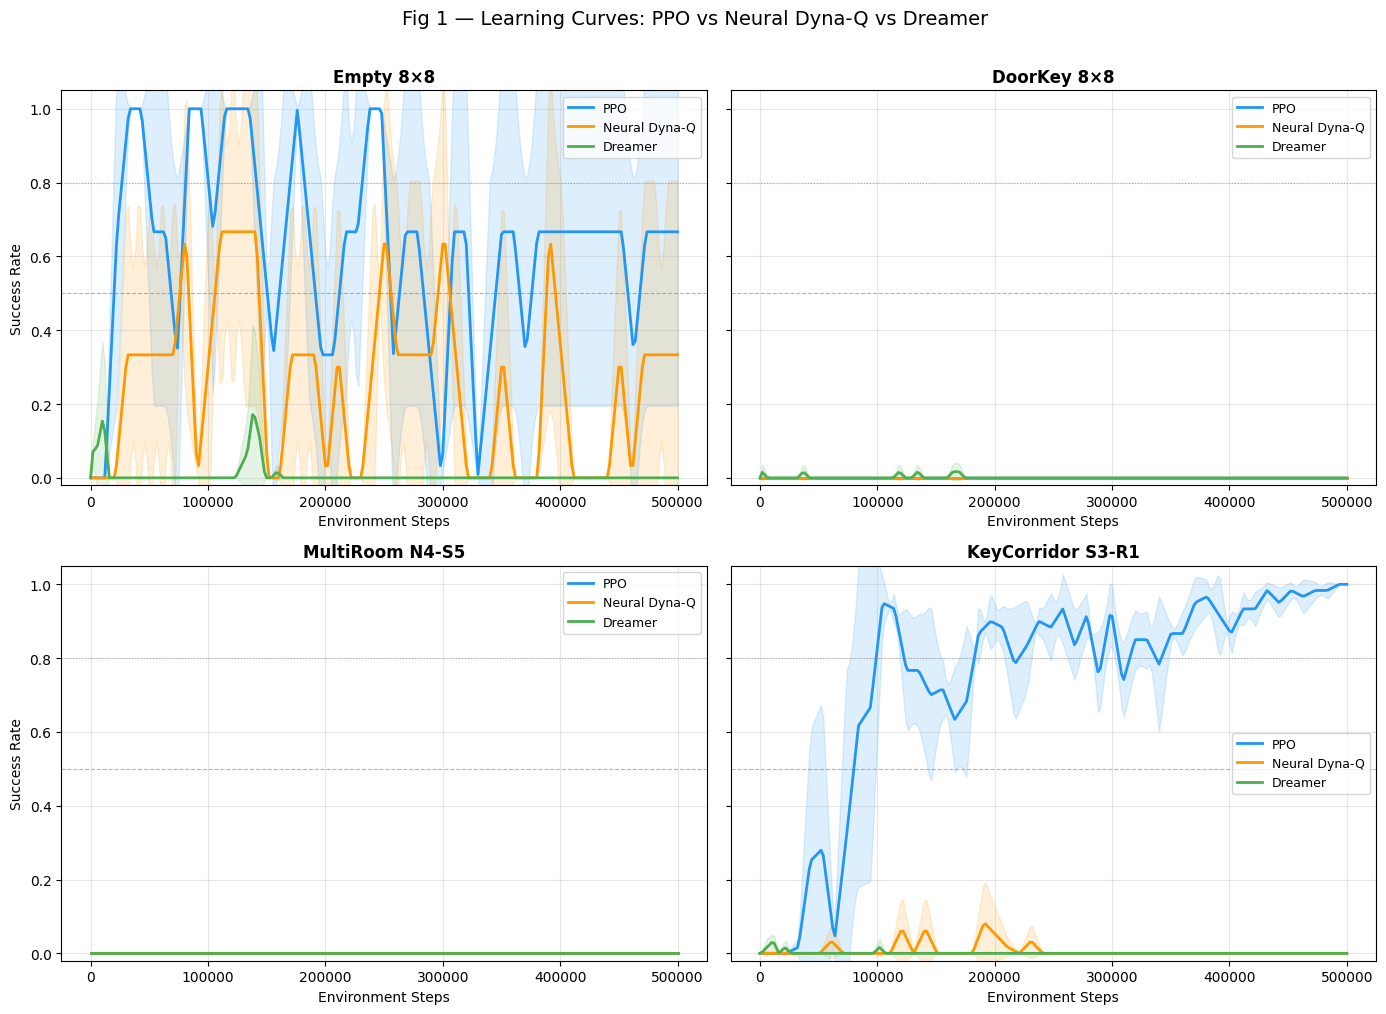

Saved: results/plots/fig1_learning_curves_2x2.png


In [14]:
import warnings
warnings.filterwarnings("ignore")

STEP_GRID = np.arange(0, 500_001, 2_000)

def interp_curve(rows, grid, col="success_rate"):
    """Interpolate a list of row dicts onto a common step grid."""
    if not rows:
        return np.full(len(grid), np.nan)
    steps = np.array([r["step"] for r in rows])
    vals  = np.array([r[col]   for r in rows])
    # Prepend (0, 0) so curves start from origin
    steps = np.concatenate([[0], steps])
    vals  = np.concatenate([[0], vals])
    return np.interp(grid, steps, vals)


def mean_std_across_seeds(env_logs, agent, grid, col="success_rate"):
    """Compute mean ± std over all seeds for one (env, agent)."""
    seed_curves = [interp_curve(rows, grid, col)
                   for rows in env_logs.get(agent, {}).values()]
    if not seed_curves:
        return None, None
    arr = np.array(seed_curves)
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)


# ── Figure 1: Learning curves — 2×2 grid (one panel per env) ──────────────
env_order = ["empty", "doorkey", "multiroom", "keycorridor"]
env_titles = {"empty": "Empty 8×8", "doorkey": "DoorKey 8×8",
              "multiroom": "MultiRoom N4-S5", "keycorridor": "KeyCorridor S3-R1"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, env in zip(axes, env_order):
    plotted = False
    for agent in ["ppo", "dynaq", "dreamer"]:
        mean, std = mean_std_across_seeds(logs.get(env, {}), agent, STEP_GRID)
        if mean is None:
            continue
        ax.plot(STEP_GRID, mean, label=AGENT_LABELS[agent],
                color=AGENT_COLORS[agent], linewidth=2)
        ax.fill_between(STEP_GRID, mean - std, mean + std,
                        alpha=0.15, color=AGENT_COLORS[agent])
        plotted = True
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axhline(0.8, color="gray", linestyle=":",  linewidth=0.8, alpha=0.6)
    ax.set_title(env_titles.get(env, env), fontsize=12, fontweight="bold")
    ax.set_xlabel("Environment Steps")
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if not plotted:
        ax.text(0.5, 0.5, "No data yet", transform=ax.transAxes,
                ha="center", va="center", color="gray", fontsize=10)

axes[0].set_ylabel("Success Rate"); axes[2].set_ylabel("Success Rate")
fig.suptitle("Fig 1 — Learning Curves: PPO vs Neural Dyna-Q vs Dreamer", fontsize=14, y=1.01)
plt.tight_layout()
out = os.path.join(SAVE_DIR, "plots", "fig1_learning_curves_2x2.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

### Fig 2 — Sample Efficiency Bar Chart

The cell below summarises learning speed as a **grouped bar chart**: 4 environment clusters on the x-axis, 3 bars per cluster (one per agent). The y-axis shows how many **thousand steps** the agent needed to *first* reach a given success-rate threshold.

Hatched bars labelled **N/R** indicate the agent never reached the threshold within the training budget. Error bars show ±1 std across seeds. This format directly matches the `fig2_sample_efficiency` output of `visualize.py`.

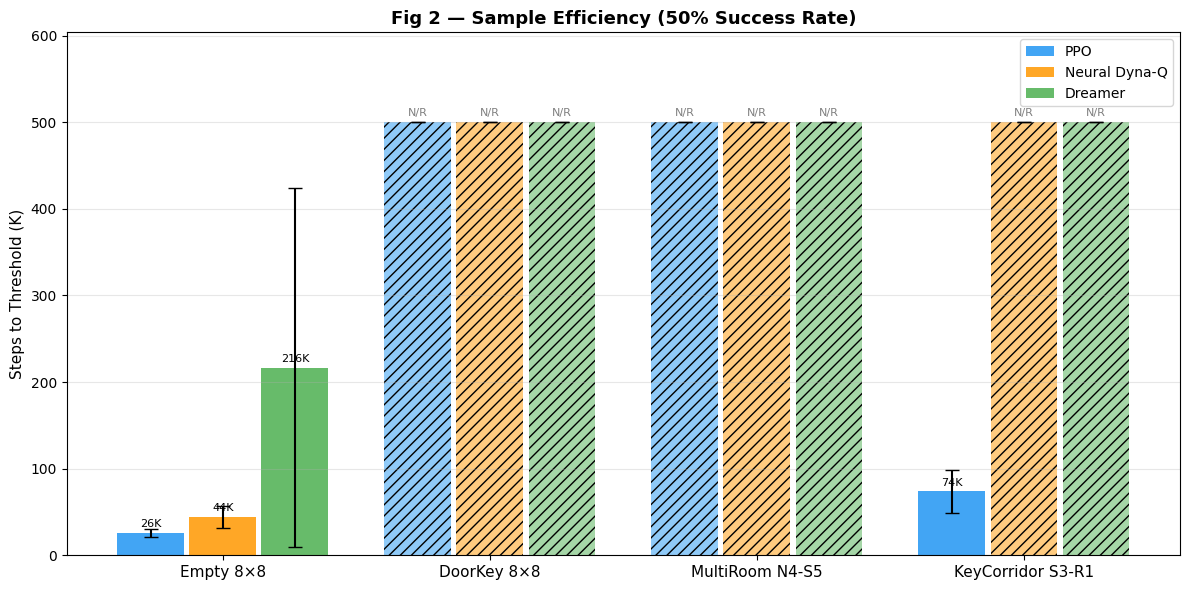

Saved: results/plots/sample_efficiency_50pct.png


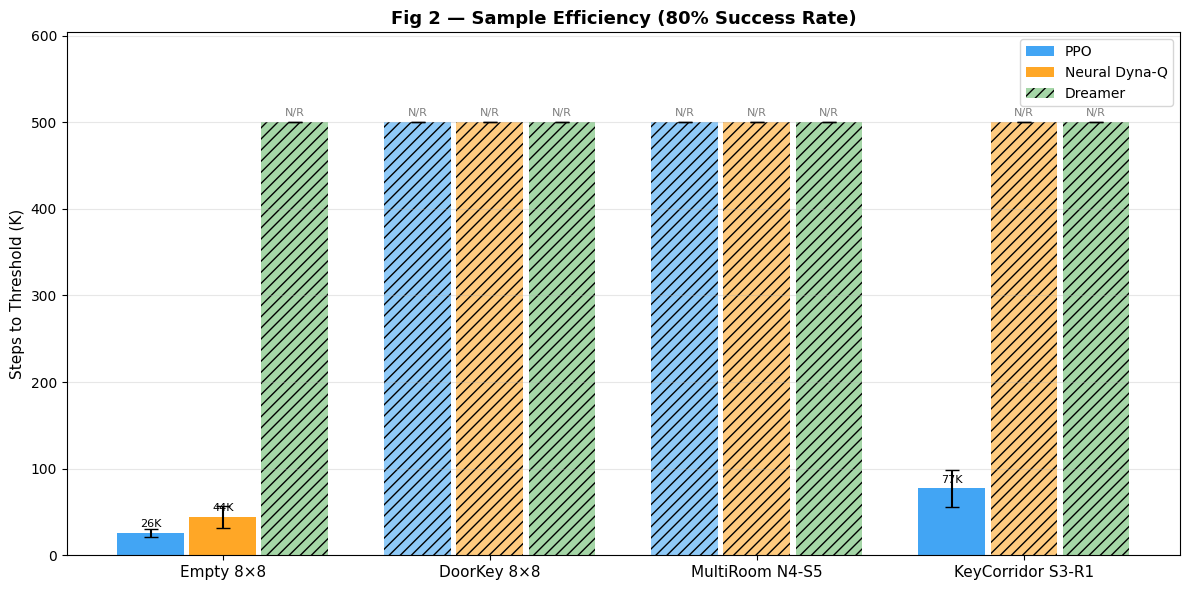

Saved: results/plots/sample_efficiency_80pct.png

Env             Agent                     Steps→50%    Steps→80%   Final SR
---------------------------------------------------------------------------
empty           PPO                          25,941       25,941      0.667
empty           Neural Dyna-Q                44,333       44,333      0.333
empty           Dreamer                      74,661          N/R      0.000

doorkey         PPO                             N/R          N/R      0.000
doorkey         Neural Dyna-Q                   N/R          N/R      0.000
doorkey         Dreamer                         N/R          N/R      0.000

multiroom       PPO                             N/R          N/R      0.000
multiroom       Neural Dyna-Q                   N/R          N/R      0.000
multiroom       Dreamer                         N/R          N/R      0.000

keycorridor     PPO                          73,728       77,141      1.000
keycorridor     Neural Dyna-Q      

In [15]:
def steps_to_threshold(rows, threshold=0.5):
    """First step where success_rate >= threshold, or np.inf."""
    for r in rows:
        if r["success_rate"] >= threshold:
            return r["step"]
    return np.inf

def wallclock_to_threshold(rows, threshold=0.5):
    """Wall-clock MINUTES to first success_rate >= threshold, or np.inf."""
    for r in rows:
        if r["success_rate"] >= threshold:
            return r.get("wall_time_sec", np.inf) / 60.0   # convert → minutes
    return np.inf


def plot_grouped_efficiency_bars(logs, threshold, ylabel, metric_fn, fname, title,
                                  cap=500.0, unit="K"):
    """Grouped bar chart: 4 env clusters × 3 agent bars. Matches visualize.py layout."""
    envs_ordered = [e for e in env_order if e in logs]
    agents_list  = ["ppo", "dynaq", "dreamer"]
    n_env        = len(envs_ordered)
    if n_env == 0:
        print(f"No data for {fname}"); return

    bar_w = 0.25
    x     = np.arange(n_env)
    fig, ax = plt.subplots(figsize=(12, 6))

    for i, agent in enumerate(agents_list):
        means, errs, never = [], [], []
        for env in envs_ordered:
            raw_vals = [metric_fn(rows, threshold)
                        for rows in logs[env].get(agent, {}).values()]
            if not raw_vals:
                raw_vals = [np.inf]
            # steps_to_threshold returns raw steps → convert to K
            if unit == "K":
                raw_vals = [v / 1_000 for v in raw_vals]
            capped = [min(v, cap) for v in raw_vals]
            hit    = [v < np.inf for v in raw_vals]
            means.append(float(np.mean(capped)))
            errs.append(float(np.std(capped)) if len(capped) > 1 else 0.0)
            never.append(not any(hit))

        offset = (i - len(agents_list) / 2 + 0.5) * (bar_w + 0.02)
        bars = ax.bar(x + offset, means, bar_w,
                      yerr=errs, capsize=5,
                      color=AGENT_COLORS[agent], label=AGENT_LABELS[agent],
                      alpha=0.85, error_kw={"elinewidth": 1.5})

        for bar, nev in zip(bars, never):
            h = bar.get_height()
            if nev:
                bar.set_hatch("///"); bar.set_alpha(0.5)
                ax.text(bar.get_x() + bar.get_width() / 2, h + cap * 0.01,
                        "N/R", ha="center", va="bottom", fontsize=8, color="gray")
            else:
                ax.text(bar.get_x() + bar.get_width() / 2, h + cap * 0.008,
                        f"{h:.0f}{unit}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([env_titles.get(e, e) for e in envs_ordered], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, "plots", fname)
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


# ── Figure 2a: 50% threshold ───────────────────────────────────────────────
plot_grouped_efficiency_bars(
    logs, threshold=0.5,
    ylabel="Steps to Threshold (K)",
    metric_fn=steps_to_threshold,
    fname="sample_efficiency_50pct.png",
    title="Fig 2 — Sample Efficiency (50% Success Rate)",
    cap=500.0, unit="K")

# ── Figure 2b: 80% threshold ───────────────────────────────────────────────
plot_grouped_efficiency_bars(
    logs, threshold=0.8,
    ylabel="Steps to Threshold (K)",
    metric_fn=steps_to_threshold,
    fname="sample_efficiency_80pct.png",
    title="Fig 2 — Sample Efficiency (80% Success Rate)",
    cap=500.0, unit="K")

# ── Numeric table ──────────────────────────────────────────────────────────
print(f"\n{'Env':<15} {'Agent':<22} {'Steps→50%':>12} {'Steps→80%':>12} {'Final SR':>10}")
print("-" * 75)
for env in env_order:
    if env not in logs:
        continue
    for agent in ["ppo", "dynaq", "dreamer"]:
        if agent not in logs[env]:
            continue
        all_seeds = list(logs[env][agent].values())
        s50_list  = [steps_to_threshold(r, 0.5) for r in all_seeds]
        s80_list  = [steps_to_threshold(r, 0.8) for r in all_seeds]
        final_sr  = np.mean([r[-1]["success_rate"] for r in all_seeds if r])
        s50 = f"{np.mean([v for v in s50_list if np.isfinite(v)]):,.0f}" if any(np.isfinite(v) for v in s50_list) else "N/R"
        s80 = f"{np.mean([v for v in s80_list if np.isfinite(v)]):,.0f}" if any(np.isfinite(v) for v in s80_list) else "N/R"
        print(f"{env:<15} {AGENT_LABELS[agent]:<22} {s50:>12} {s80:>12} {final_sr:>10.3f}")
    print()

## 12. Fig 2 & 3 — Sample Efficiency, Wall-Clock Time & Grad Norm

**Fig 2 — Sample Efficiency**: Grouped bar chart with 4 env clusters and 3 bars per cluster (one per agent). Y-axis: thousand-step (K) counts needed to *first* reach 50% or 80% success. Hatched **N/R** bars = run never reached the threshold. Error bars = ±1 std across seeds.

- Shorter bar → more sample-efficient. N/R on hard envs (KeyCorridor, MultiRoom) indicates model-free PPO often fails to explore enough within budget.

**Fig 3 — Wall-clock Time**: Same grouped layout but y-axis shows *wall-clock minutes* to 80% success. Captures both sample efficiency and per-step compute cost. Dreamer has expensive world-model updates per step; PPO and Dyna-Q are cheaper.

**Grad Norm**: EMA of the pre-clip gradient norm for each agent's primary network. Exploding or vanishing norms indicate training instability.

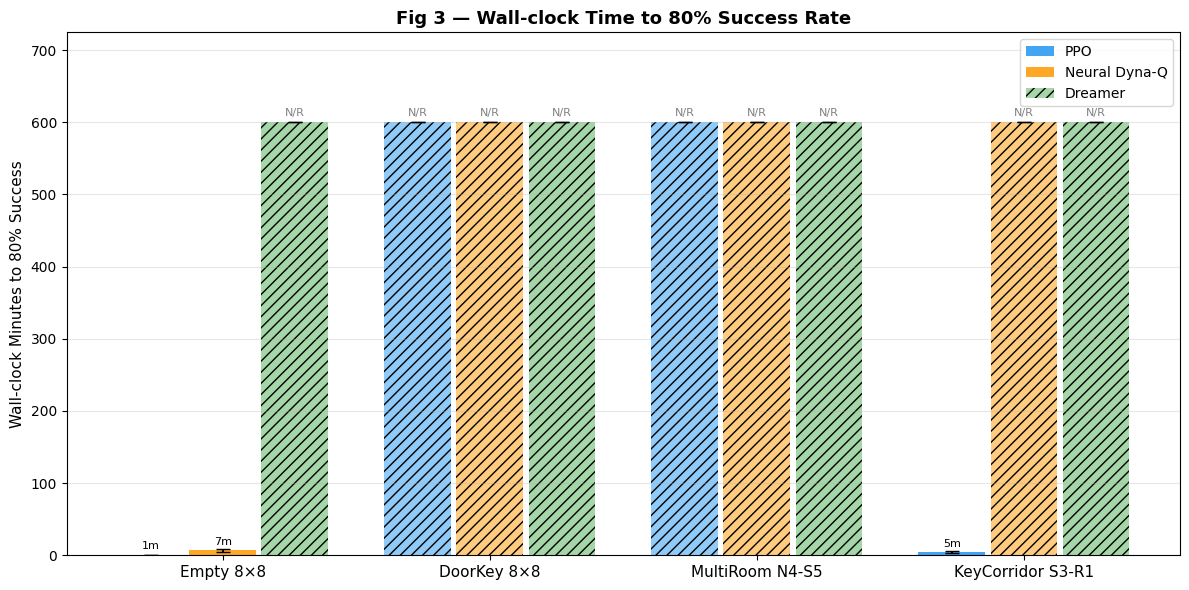

Saved: results/plots/wallclock.png


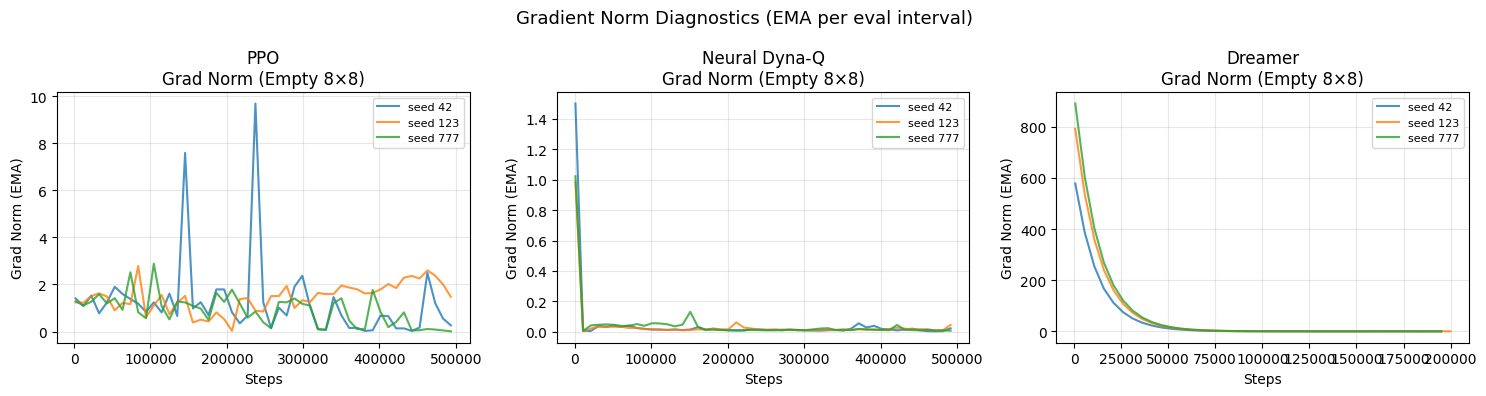

Saved: results/plots/grad_norm_diagnostics.png


In [16]:
# ── Figure 3: Wall-clock time to 80% success (in minutes) ────────────────
# wallclock_to_threshold now returns minutes (defined in 'sample-efficiency' cell)
plot_grouped_efficiency_bars(
    logs, threshold=0.8,
    ylabel="Wall-clock Minutes to 80% Success",
    metric_fn=wallclock_to_threshold,
    fname="wallclock.png",
    title="Fig 3 — Wall-clock Time to 80% Success Rate",
    cap=600.0, unit="m")

# ── Grad norm over training steps ─────────────────────────────────────────
envs_with_data = [e for e in env_order if e in logs]
if envs_with_data:
    env_plot = envs_with_data[0]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, agent in zip(axes, ["ppo", "dynaq", "dreamer"]):
        has_gnorm = False
        for seed, rows in sorted(logs[env_plot].get(agent, {}).items()):
            if not rows or "grad_norm" not in rows[0]:
                continue
            has_gnorm = True
            steps = [r["step"] for r in rows]
            gnorm = [r["grad_norm"] for r in rows]
            ax.plot(steps, gnorm, alpha=0.8, label=f"seed {seed}")
        ax.set_title(f"{AGENT_LABELS[agent]}\nGrad Norm ({env_titles.get(env_plot, env_plot)})")
        ax.set_xlabel("Steps"); ax.set_ylabel("Grad Norm (EMA)")
        ax.grid(alpha=0.3)
        if has_gnorm:
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, "No grad_norm column\n(run after new benchmark)",
                    transform=ax.transAxes, ha="center", va="center",
                    color="gray", fontsize=9)

    fig.suptitle("Gradient Norm Diagnostics (EMA per eval interval)", fontsize=13)
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, "plots", "grad_norm_diagnostics.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
else:
    print("No training data available yet — run §9 or §10 first.")

## 13. Fig 4 — Generalization Heatmap (zero-shot 8×8 → 16×16)

After training on the standard 8×8 environment, the best checkpoint is evaluated **zero-shot** on the corresponding 16×16 variant. The CNN encoder uses `AdaptiveAvgPool2d(4, 4)` so it handles any observation size without architectural changes.

Two heatmaps side-by-side:
- **Left (RdYlGn)**: Absolute zero-shot success rate on 16×16 — green = good generalisation.
- **Right (RdYlGn_r)**: Drop in success (8×8 train SR − 16×16 gen SR) — red = large degradation.

> Requires `--eval_generalization` during training (§10). Set `RUN_GEN_EVAL = True` below to trigger post-hoc eval on the most recent checkpoint.

In [17]:
# ── (Optional) Run generalization eval on best checkpoints ────────────────
env_order = ["empty", "doorkey", "multiroom", "keycorridor"]  # ensure defined
RUN_GEN_EVAL = True   # Set True after full training to evaluate 16×16 generalization

if RUN_GEN_EVAL:
    gen_path = os.path.join(SAVE_DIR, "tables", "generalization_results.csv")
    for agent in AGENTS:
        for env in ENVS:
            tmp_env = make_env(env, seed=0)
            obs_shape_env = tmp_env.observation_space.shape
            n_actions_env = tmp_env.action_space.n
            tmp_env.close()
            for seed in SEEDS:
                ckpt = _find_latest_checkpoint(SAVE_DIR, agent, env, seed)
                if ckpt is None:
                    print(f"  [SKIP] {agent}/{env}/seed{seed}: no checkpoint")
                    continue
                print(f"  [GEN] {agent}/{env}/seed{seed} → {GEN_ENV_MAP.get(env, '?')} ...")
                rate = load_checkpoint_and_eval_generalization(
                    agent, ckpt, env, obs_shape_env, n_actions_env, DEVICE)
                _append_gen_result(gen_path, agent, env, seed, rate)
                print(f"        success rate = {rate:.3f}")
    print(f"Generalization results saved to {gen_path}")

# ── Plot generalization heatmap if CSV exists ──────────────────────────────
gen_csv = os.path.join(SAVE_DIR, "tables", "generalization_results.csv")
if os.path.exists(gen_csv):
    import pandas as pd
    gen_df = pd.read_csv(gen_csv)

    # Average over seeds
    gen_mean = gen_df.groupby(["agent", "env"])["gen_success_rate_16x16"].mean().reset_index()

    # Also get 8×8 final success from training logs
    train_sr = {}
    for env in env_order:
        for agent in ["ppo", "dynaq", "dreamer"]:
            sr_vals = [rows[-1]["success_rate"]
                       for rows in logs.get(env, {}).get(agent, {}).values() if rows]
            if sr_vals:
                train_sr[(agent, env)] = np.mean(sr_vals)

    # Build pivot tables
    gen_pivot  = gen_mean.pivot(index="agent", columns="env", values="gen_success_rate_16x16")
    train_pivot = pd.DataFrame({
        env: {agent: train_sr.get((agent, env), np.nan) for agent in ["ppo", "dynaq", "dreamer"]}
        for env in env_order
    })
    delta_pivot = train_pivot - gen_pivot.reindex(columns=env_order)

    try:
        import seaborn as sns
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        kw = {"annot": True, "fmt": ".2f", "linewidths": 0.5, "vmin": 0, "vmax": 1}
        sns.heatmap(gen_pivot[env_order],  ax=axes[0], cmap="RdYlGn", **kw)
        sns.heatmap(delta_pivot[env_order], ax=axes[1], cmap="RdYlGn_r",
                    annot=True, fmt=".2f", linewidths=0.5)
        axes[0].set_title("Fig 4a — 16×16 Gen Success Rate")
        axes[1].set_title("Fig 4b — Train 8×8 − Gen 16×16 (gap)")
        plt.tight_layout()
        out = os.path.join(SAVE_DIR, "plots", "fig4_generalization_heatmap.png")
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out}")
    except ImportError:
        print("seaborn not installed — pip install seaborn")
        print(gen_mean.to_string())
else:
    print(f"No generalization data yet.")
    print(f"Set RUN_GEN_EVAL=True above (after full training) OR run:")
    print(f"  python benchmark.py --agent ppo --env empty --seed 42 "
          f"--total_steps 500000 --eval_generalization")

  [GEN] ppo/empty/seed42 → MiniGrid-Empty-16x16-v0 ...
        success rate = 0.000
  [GEN] ppo/empty/seed123 → MiniGrid-Empty-16x16-v0 ...
        success rate = 0.000
  [GEN] ppo/empty/seed777 → MiniGrid-Empty-16x16-v0 ...
        success rate = 0.000
  [GEN] ppo/doorkey/seed42 → MiniGrid-DoorKey-16x16-v0 ...
        success rate = 0.000
  [GEN] ppo/doorkey/seed123 → MiniGrid-DoorKey-16x16-v0 ...
        success rate = 0.000
  [GEN] ppo/doorkey/seed777 → MiniGrid-DoorKey-16x16-v0 ...
        success rate = 0.000
  [GEN] ppo/multiroom/seed42 → MiniGrid-MultiRoom-N6-v0 ...
        success rate = 0.000
  [GEN] ppo/multiroom/seed123 → MiniGrid-MultiRoom-N6-v0 ...
        success rate = 0.000
  [GEN] ppo/multiroom/seed777 → MiniGrid-MultiRoom-N6-v0 ...
        success rate = 0.000
  [GEN] ppo/keycorridor/seed42 → MiniGrid-KeyCorridorS4R3-v0 ...
        success rate = 0.000
  [GEN] ppo/keycorridor/seed123 → MiniGrid-KeyCorridorS4R3-v0 ...
        success rate = 0.000
  [GEN] ppo/keycorrido

RuntimeError: Error(s) in loading state_dict for RSSM:
	size mismatch for decoder.4.weight: copying a param with shape torch.Size([1875, 512]) from checkpoint, the shape in current model is torch.Size([192, 512]).
	size mismatch for decoder.4.bias: copying a param with shape torch.Size([1875]) from checkpoint, the shape in current model is torch.Size([192]).

## 14. Fig 10 & 11 — Ablation Sweeps

### Fig 10 — Dyna-Q Planning Ratio k (DoorKey-8×8, seed 42)

Sweeps `k ∈ {0, 1, 5, 10, 20}` with 200K steps. The default `k=5` run from §10 is included.

- `k=0` → pure DQN (no imagination); higher k → more imagined Q-updates per real step
- Dotted vertical lines mark first step each k reaches 80% success
- **What to look for**: optimal k? Does k=0 learn? Do large k values hurt (model error compounding)?

### Fig 11 — Dreamer Imagination Horizon H (MultiRoom-N4-S5, seed 42)

Sweeps `H ∈ {5, 10, 15, 20, 25}` with 200K steps. MultiRoom has the longest credit-assignment chain — H matters most here.

- Short H → poor credit propagation; Long H → compounding imagination errors
- Default H=15 run included from §10

> Set `RUN_ABLATIONS = True` below to launch sweeps (~1–2h per sweep on T4 GPU).

In [ ]:
RUN_ABLATIONS = True   # Set True to run ablation sweeps (takes ~1–2h each)

if RUN_ABLATIONS:
    print("Running Dyna-Q k ablation (doorkey, seed 42, 200K steps)...")
    ab_k_dir = os.path.join(SAVE_DIR, "ablation_k")
    os.makedirs(os.path.join(ab_k_dir, "logs"),        exist_ok=True)
    os.makedirs(os.path.join(ab_k_dir, "checkpoints"), exist_ok=True)
    for k in [0, 1, 10, 20]:   # k=5 is already in results/logs/
        print(f"  k={k}")
        train_dynaq("doorkey", seed=42, total_steps=200_000,
                    save_dir=ab_k_dir, device=DEVICE, planning_k=k)

    print("\nRunning Dreamer H ablation (multiroom, seed 42, 200K steps)...")
    ab_h_dir = os.path.join(SAVE_DIR, "ablation_h")
    os.makedirs(os.path.join(ab_h_dir, "logs"),        exist_ok=True)
    os.makedirs(os.path.join(ab_h_dir, "checkpoints"), exist_ok=True)
    for h in [5, 10, 20, 25]:  # H=15 is already in results/logs/
        print(f"  H={h}")
        train_dreamer("multiroom", seed=42, total_steps=200_000,
                      save_dir=ab_h_dir, device=DEVICE, imagination_h=h)
    print("Ablations complete. Re-run load cell then the plot cells below.")


# Reload ablation data from disk
def load_ablation_logs(ablation_dir):
    log_dir = os.path.join(ablation_dir, "logs")
    if not os.path.isdir(log_dir):
        return {}
    _, ab_k, ab_h = load_all_logs(log_dir)
    return ab_k, ab_h

ab_k_dir = os.path.join(SAVE_DIR, "ablation_k")
ab_h_dir = os.path.join(SAVE_DIR, "ablation_h")

if os.path.isdir(ab_k_dir):
    ablation_k_data, _ = load_ablation_logs(ab_k_dir)
if os.path.isdir(ab_h_dir):
    _, ablation_h_data = load_ablation_logs(ab_h_dir)

# Also try to add k=5 default from main results
k5_rows = logs.get("doorkey", {}).get("dynaq", {})
if k5_rows and 5 not in ablation_k_data:
    ablation_k_data[5] = list(k5_rows.values())[0] if k5_rows else []

# And H=15 from main results
h15_rows = logs.get("multiroom", {}).get("dreamer", {})
if h15_rows and 15 not in ablation_h_data:
    ablation_h_data[15] = list(h15_rows.values())[0] if h15_rows else []

print(f"Ablation k data: k ∈ {sorted(ablation_k_data.keys())}")
print(f"Ablation H data: H ∈ {sorted(ablation_h_data.keys())}")

In [ ]:
# ── Figure 10: Ablation k ─────────────────────────────────────────────────
if ablation_k_data:
    k_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ablation_k_data)))
    fig, ax = plt.subplots(figsize=(9, 5))
    for (k, rows), color in zip(sorted(ablation_k_data.items()), k_colors):
        if not rows:
            continue
        curve = interp_curve(rows, STEP_GRID)
        ax.plot(STEP_GRID, curve, label=f"k={k}", color=color, linewidth=2)
        # Mark first step at 80%
        thresh_step = steps_to_threshold(rows, 0.8)
        if np.isfinite(thresh_step):
            ax.axvline(thresh_step, color=color, linestyle=":", alpha=0.5)
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=0.8, label="80% threshold")
    ax.set_xlabel("Environment Steps"); ax.set_ylabel("Success Rate")
    ax.set_title("Fig 10 — Dyna-Q Planning Ratio k (DoorKey, seed 42)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, "plots", "fig10_ablation_planning_ratio_k.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
else:
    print("No ablation k data — set RUN_ABLATIONS=True in cell above.")

# ── Figure 11: Ablation H ─────────────────────────────────────────────────
if ablation_h_data:
    h_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(ablation_h_data)))
    fig, ax = plt.subplots(figsize=(9, 5))
    for (h, rows), color in zip(sorted(ablation_h_data.items()), h_colors):
        if not rows:
            continue
        curve = interp_curve(rows, STEP_GRID)
        ax.plot(STEP_GRID, curve, label=f"H={h}", color=color, linewidth=2)
        thresh_step = steps_to_threshold(rows, 0.8)
        if np.isfinite(thresh_step):
            ax.axvline(thresh_step, color=color, linestyle=":", alpha=0.5)
    ax.axhline(0.8, color="gray", linestyle="--", linewidth=0.8, label="80% threshold")
    ax.set_xlabel("Environment Steps"); ax.set_ylabel("Success Rate")
    ax.set_title("Fig 11 — Dreamer Imagination Horizon H (MultiRoom, seed 42)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, "plots", "fig11_ablation_imagination_h.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
else:
    print("No ablation H data — set RUN_ABLATIONS=True in cell above.")

## 16. Additional Diagnostics — Loss Curves, Episode Length, Stability & Summary

The cells below produce supplementary figures giving deeper insight into training dynamics. All figures are saved to `SAVE_DIR/plots/` using the same filenames as `visualize.py`.

| Figure | File | What it shows |
|--------|------|---------------|
| Loss curves | `loss_curves_{agent}.png` | Per-agent training losses across all envs |
| Episode length | `episode_length_curves.png` | Leading indicator of learning before success rate rises |
| Mean return | `return_curves.png` | Raw reward signal per episode |
| Per-seed variance | `per_seed_variance.png` | Individual seeds vs mean — training stability |
| Summary table | `summary_table.csv` | 12-row table with final SR, steps-to-threshold, wall-clock, gen rate |

### Loss Diagnostic Curves

One figure per agent, showing the training losses over steps for each environment (4 coloured lines per subplot, mean ± 1 std across seeds):

| Agent | Loss columns |
|-------|-------------|
| PPO | `policy_loss`, `value_loss`, `entropy` |
| Neural Dyna-Q | `q_loss`, `model_loss`, `epsilon` |
| Dreamer | `wm_loss`, `recon_loss`, `kl_loss`, `actor_loss`, `critic_loss` |

A decreasing policy/Q loss and increasing entropy signal healthy training. For Dreamer, watch the KL loss — if it collapses, the posterior is ignoring the prior (posterior collapse).

In [ ]:
# ── Loss diagnostic curves — one figure per agent ─────────────────────────
_LOSS_COLS = {
    "ppo":     ["policy_loss", "value_loss", "entropy"],
    "dynaq":   ["q_loss", "model_loss", "epsilon"],
    "dreamer": ["wm_loss", "recon_loss", "kl_loss", "actor_loss", "critic_loss"],
}
_LOSS_LABELS = {
    "policy_loss": "Policy Loss", "value_loss": "Value Loss", "entropy": "Entropy",
    "q_loss": "Q-Network Loss", "model_loss": "Model Loss", "epsilon": "ε-greedy",
    "wm_loss": "World Model Loss", "recon_loss": "Recon Loss", "kl_loss": "KL Loss",
    "actor_loss": "Actor Loss", "critic_loss": "Critic Loss",
}
_ENV_COLORS = ["#E91E63", "#9C27B0", "#00BCD4", "#FF5722"]

for _agent, _cols in _LOSS_COLS.items():
    _avail = []
    for _col in _cols:
        for _env in env_order:
            for _rows in logs.get(_env, {}).get(_agent, {}).values():
                if _rows and _col in _rows[0]:
                    _avail.append(_col); break
            else:
                continue
            break

    if not _avail:
        print(f"No loss columns for {_agent} — re-run benchmark to generate them."); continue

    fig, axes = plt.subplots(1, len(_avail), figsize=(5 * len(_avail), 5))
    if len(_avail) == 1: axes = [axes]

    for ax, _col in zip(axes, _avail):
        _has = False
        for _env, _ec in zip(env_order, _ENV_COLORS):
            _curves = []
            for _rows in logs.get(_env, {}).get(_agent, {}).values():
                if _rows and _col in _rows[0]:
                    _curves.append(interp_curve(_rows, STEP_GRID, col=_col))
            if not _curves: continue
            _has = True
            _arr = np.array(_curves)
            _m = np.nanmean(_arr, axis=0); _s = np.nanstd(_arr, axis=0)
            ax.plot(STEP_GRID / 1_000, _m, color=_ec, linewidth=2,
                    label=env_titles.get(_env, _env))
            ax.fill_between(STEP_GRID / 1_000, _m - _s, _m + _s, alpha=0.15, color=_ec)
        ax.set_title(_LOSS_LABELS.get(_col, _col), fontsize=12, fontweight="bold")
        ax.set_xlabel("Steps (K)"); ax.set_ylabel(_LOSS_LABELS.get(_col, _col))
        ax.grid(True, alpha=0.3)
        if _has: ax.legend(fontsize=8)

    fig.suptitle(f"Loss Diagnostics — {AGENT_LABELS[_agent]}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, "plots", f"loss_curves_{_agent}.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

### Episode Length & Mean Return Curves

Beyond success rate, two signals reveal learning progress *before* success rate changes:
- **Episode length**: When agents learn nothing, episodes time out at the max step limit. Shorter episodes indicate the agent is reaching goals faster — a leading indicator of learning even when success rate is still near 0.
- **Mean return**: Raw reward accumulated per episode. Correlates with success rate in sparse settings but also captures partial rewards when present.

These 2×2 grids mirror Figure 1's layout and are saved as matching PNG files.

In [ ]:
# ── Episode length & mean return — 2×2 grid ──────────────────────────────
for _col, _ylabel, _title, _fname in [
    ("mean_ep_length", "Mean Episode Length (steps)",
     "Episode Length — Shorter = Faster Goal Reaching",  "episode_length_curves.png"),
    ("mean_return",    "Mean Episode Return",
     "Mean Return Curves — PPO vs Dyna-Q vs Dreamer",    "return_curves.png"),
]:
    _has_col = any(
        _col in rows[0] if rows else False
        for _e in env_order
        for _ad in logs.get(_e, {}).values()
        for rows in _ad.values()
    )
    if not _has_col:
        print(f"Column '{_col}' not in logs yet — run experiments first."); continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for ax, env in zip(axes, env_order):
        for agent in ["ppo", "dynaq", "dreamer"]:
            _curves = []
            for rows in logs.get(env, {}).get(agent, {}).values():
                if rows and _col in rows[0]:
                    _curves.append(interp_curve(rows, STEP_GRID, col=_col))
            if not _curves:
                continue
            _arr  = np.array(_curves)
            _mean = np.nanmean(_arr, axis=0)
            _std  = np.nanstd(_arr, axis=0)
            ax.plot(STEP_GRID / 1_000, _mean, color=AGENT_COLORS[agent],
                    linewidth=2.5, label=AGENT_LABELS[agent])
            ax.fill_between(STEP_GRID / 1_000, _mean - _std, _mean + _std,
                            alpha=0.15, color=AGENT_COLORS[agent])
        ax.set_title(env_titles.get(env, env), fontsize=14, fontweight="bold")
        ax.set_xlabel("Steps (K)"); ax.set_ylabel(_ylabel)
        ax.set_xlim(0, 500); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle(_title, fontsize=15, y=1.01)
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, "plots", _fname)
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

### Per-Seed Variance — Training Stability

This figure overlays individual seed runs (thin semi-transparent lines) behind the thick mean line for the easiest environment (Empty-8×8). Wide spread between seeds = **high training variance** (sensitive to random initialisation or exploration luck). Tight clustering = reliable, reproducible learning.

If variance is high even on the easy env, the agent's performance is noisy and results should be interpreted cautiously on harder envs.

In [ ]:
# ── Per-seed variance — training stability (Empty-8×8) ───────────────────
_env_var = "empty"
if _env_var in logs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, agent in zip(axes, ["ppo", "dynaq", "dreamer"]):
        color = AGENT_COLORS[agent]
        all_curves = []
        for seed, rows in sorted(logs[_env_var].get(agent, {}).items()):
            curve = interp_curve(rows, STEP_GRID)
            all_curves.append(curve)
            ax.plot(STEP_GRID / 1_000, curve, color=color, linewidth=1.2, alpha=0.4,
                    label=f"seed {seed}")
        if all_curves:
            _mean = np.nanmean(np.array(all_curves), axis=0)
            ax.plot(STEP_GRID / 1_000, _mean, color=color, linewidth=3,
                    label=f"Mean (n={len(all_curves)})")
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
        ax.axhline(0.8, color="gray", linestyle="--", alpha=0.4)
        ax.set_title(AGENT_LABELS[agent], fontsize=12, fontweight="bold")
        ax.set_xlabel("Steps (K)"); ax.set_ylabel("Success Rate")
        ax.set_xlim(0, 500); ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    fig.suptitle("Per-Seed Variance — Empty-8×8 (Training Stability)", fontsize=14, y=1.01)
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, "plots", "per_seed_variance.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
else:
    print("No 'empty' env data — run §9 or §10 first.")

### Summary Table — Comprehensive per-(agent, env) statistics

Aggregates 8 metrics across all 12 (agent × env) combinations. Color shading shows final success rate and generalization rate (green = good). `N/A` = never reached threshold within budget.

| Column | Meaning |
|--------|---------|
| `final_sr_mean/std` | Mean ± std of last-eval success rate across seeds |
| `steps_to_50/80K` | K steps to first reach threshold, averaged across seeds |
| `wallclock_80_min` | Wall-clock minutes to 80% success |
| `gen_rate_16x16` | Zero-shot success on 16×16 variant (NaN if gen eval not run) |

In [ ]:
# ── Comprehensive summary table ───────────────────────────────────────────
try:
    import pandas as pd
    _has_pandas = True
except ImportError:
    _has_pandas = False
    print("pandas not installed — summary table will be text only.")

_rows_summary = []
_gen_csv = os.path.join(SAVE_DIR, "tables", "generalization_results.csv")
_gen_df  = None
if _has_pandas and os.path.exists(_gen_csv):
    try:
        _gen_df = pd.read_csv(_gen_csv)
    except Exception:
        pass

def _clean(v):
    """Return v if finite, else nan (handles both np.inf and float('inf'))."""
    return float("nan") if not np.isfinite(v) else v

for _agent in ["ppo", "dynaq", "dreamer"]:
    for _env in env_order:
        _seed_data = logs.get(_env, {}).get(_agent, {})

        if not _seed_data:
            _rows_summary.append({"agent": _agent, "env": _env,
                "final_sr_mean": float("nan"), "final_sr_std": float("nan"),
                "steps_to_50K": float("nan"), "steps_to_80K": float("nan"),
                "wallclock_80_min": float("nan"), "gen_rate_16x16": float("nan")})
            continue

        _all    = list(_seed_data.values())
        _finals = [r[-1]["success_rate"] for r in _all if r]
        _s50    = [_clean(steps_to_threshold(r, 0.5) / 1_000) for r in _all]
        _s80    = [_clean(steps_to_threshold(r, 0.8) / 1_000) for r in _all]
        _wc80   = [_clean(wallclock_to_threshold(r, 0.8)) for r in _all]   # already minutes

        _gen = float("nan")
        if _gen_df is not None:
            _m = (_gen_df["agent"] == _agent) & (_gen_df["env"] == _env)
            if _m.any():
                _gen = float(_gen_df.loc[_m, "gen_success_rate_16x16"].mean())

        _rows_summary.append({
            "agent": _agent, "env": _env,
            "final_sr_mean": round(float(np.mean(_finals)), 3) if _finals else float("nan"),
            "final_sr_std":  round(float(np.std(_finals)), 3)  if _finals else float("nan"),
            "steps_to_50K":  round(float(np.nanmean(_s50)), 1),
            "steps_to_80K":  round(float(np.nanmean(_s80)), 1),
            "wallclock_80_min": round(float(np.nanmean(_wc80)), 1),
            "gen_rate_16x16": round(_gen, 3) if np.isfinite(_gen) else float("nan"),
        })

if _has_pandas:
    _summary = pd.DataFrame(_rows_summary)
    os.makedirs(os.path.join(SAVE_DIR, "tables"), exist_ok=True)
    _csv_out = os.path.join(SAVE_DIR, "tables", "summary_table.csv")
    _summary.to_csv(_csv_out, index=False)
    print(f"Saved: {_csv_out}")
    print("\n=== Summary Table ===")
    print(_summary.to_string(index=False))
    try:
        from IPython.display import display
        display(_summary.style
            .background_gradient(subset=["final_sr_mean", "gen_rate_16x16"],
                                  cmap="RdYlGn", vmin=0, vmax=1)
            .format({"final_sr_mean": "{:.3f}", "final_sr_std": "{:.3f}",
                     "steps_to_50K": "{:.0f}K", "steps_to_80K": "{:.0f}K",
                     "wallclock_80_min": "{:.0f}m", "gen_rate_16x16": "{:.3f}"},
                    na_rep="N/A"))
    except Exception:
        pass
else:
    print(f"{'Agent':<10} {'Env':<15} {'SR mean':>9} {'SR std':>8} {'50K':>8} {'80K':>8} {'WC80m':>8}")
    print("-" * 70)
    for r in _rows_summary:
        print(f"{r['agent']:<10} {r['env']:<15} {r['final_sr_mean']:>9.3f} "
              f"{r['final_sr_std']:>8.3f} {r['steps_to_50K']:>8.1f} "
              f"{r['steps_to_80K']:>8.1f} {r['wallclock_80_min']:>8.1f}")

## 15. Download Results

Zips `results/` (logs, checkpoints, plots, tables) and downloads to your machine.

In [ ]:
import shutil
shutil.make_archive("results_final", "zip", "results")
from google.colab import files
files.download("results_final.zip")

In [ ]:
# (duplicate download cell — disabled)
print("Use the results_final.zip download above.")